# ECS7024P Statistics for Data Science and AI: Coursework 3

## Statistical Analysis of UK Weather Data and Assessment of Evidence of Changing Climate

### Kate Chamberlain - 220755652


This report carries out a statistical analysis of historic UK weather data and assesses evidence of changing climate and any variation across the country. 

The analysis has been structured using four sections: 

-  Qualitative Evidence for Changing Climate 
-  Trends in Monthly Average of Daily Maximum Temperatures  
-  Trends in Monthly Air Frost Days
-  Examination of Statistical Evidence

## Contents

1. **Data Preparation**   
    1.1 Dataset: UK Historic Weather Data  
    1.2 Loading the data  
    1.3 Data Cleaning and Structure  
    1.4 Missing Data Audit  
    1.5 Variation in Station Operation Periods  
    
2. **Initial Evidence for Changing Climate**  
    2.1 Station Selection   
    2.2 Maximum Temperature Trends  
    2.3 Rainfall Patterns   
    2.4 Frost Days  
    2.5 Summary of Qualitative Evidence  

3. **Trend Analysis of Monthly Average Maximum Temperature (TMax)**  
    3.1 Regression Approach
    3.2 Assessing the Quality of the Regression Fit
        3.2.1 Overview of Regression Fit Across All Stations
        3.2.2 Examination of Regression Fit for Selected Stations
    3.3 Bootstrap Confidence Intervals for Long-Term Temperature Trends
        3.3.1 Bootstrap Procedure
        3.3.2 Confidence Intervals for β₁ Across All Stations
        3.3.3 Bootstrap Distributions for Selected Stations
    3.4
        3.4.1 Bootstrap Procedure
        3.4.2   Results for selected stations

4. **Changing Pattern of Air Frost Days**
    4.1 Handling Frost Data
    4.2 Chi-squared Tests of Independence

5. **Examination of Statistical Evidence**
    5.1 Evidence for climate change 
    5.2 Regional Variation  
    5.3 Data Reliability and Limitations  
    5.4 Recommendations for Future Work 



## 1. Data Preparation 

All 37 of the weather CSV files will be used in the analysis, along with the weather station meta data. In this section the data is loaded and the data is reviewed and prepared for analysis. This includes reviewing missing values, differing data collection periods, and adding required calculated columns to the data. 

### 1.1 Dataset: UK Historic Weather Data

The dataset used for this analysis consists of 37 CSV files, each containing historic data for a UK weather station. The table below summarises the weather data (the structure is consistent across the CSV files). 

| **Variable (units)**    |      **Description**             |
|:--------------|:-----------------------------|
|Year   | Year of data collection                  |
|Month         | Month of data collection                             | 
|TMax (degC)  | Daily maximum, average for month, degrees Celsius           |
|TMin (DegC)  | Daily minimum, average for month, degrees Celsius | 
|Frost (days)      | Number of days with air frost |
|Rainfall (mm)     | Rainfall in mm           | category |
|Sunshine (hr)        | Hours of sunshine each day, average for month   |
|Status    | Whether data record is confirmed or provisional |

An additional file contains metadata on the 37 stations: name, location, year opened, and latest year of data. Most of the stations are still operating but some have closed. 

The data source is https://www.metoffice.gov.uk/research/climate/maps-and-data/historicstation-data



### 1.2 Loading the data 



In [1]:
# Load packages used in notebook 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import scipy.stats as stats
import datetime

%matplotlib inline

The weather station metadata is loaded and stored as a DataFrame, `meta_df`. The first 5 rows are displayed below. 

In [2]:
# Load in weather station metadata
meta_df = pd.read_csv('weather_data/ALL-WEATHER-STATIONS.csv')
meta_df.rename(columns={'Longnitude': 'Longitude'}, inplace=True)
display(meta_df.head())


,Name,Longitude,Latitude,Opened,Latest,FileName
0,Aberporth,-4.570,52.139,1941,2025,aberporthdata
1,Armagh,-6.649,54.352,1853,2025,armaghdata
2,Ballypatrick Forest,-6.153,55.181,1961,2025,ballypatrickdata
3,Bradford,-1.772,53.813,1908,2025,bradforddata
4,Braemar No 2,-3.396,57.011,1959,2025,braemardata


A helper function is defined for easy access to station metadata.

In [3]:
def get_meta(station):
    return meta_df.loc[meta_df["Station"] == station].iloc[0]

For each weather station, the historic weather data file is passed to the loading function. The function saves the file contents as a DataFrame.

The loaded data for each station is saved in the dictionary `weather_data`, with the station name as the key.

In [4]:
# CSV loading function - takes lowercase file name (no .csv) as input

def load_weather_data(file_name): 
    file_path = f'weather_data/{file_name}.csv'
    df = pd.read_csv(file_path)
    df.columns = [col.strip() for col in df.columns] # Remove any whitespace from column titles
    return df

In [5]:
# Load in all 37 stations' weather data, save in dict with station name as key

weather_data = {}

for i, row in meta_df.iterrows():
    name = row.Name
    filename = row.FileName
    df = load_weather_data(filename)
    df['Station'] = name
    weather_data[name] = df

### 1.3 Data Cleaning and Structure

Columns required for later analysis are added: 

- **Time**: The source data has year and month data but, for analysis, a single, continuous time column is required. January of the earliest opening year across all of the stations is taken as month 0 and every subsequent month is assigned an integer. 
- **Date**: A datetime column, where each row is the first day of that Year-Month
- **sin(wt)**: The sine term used for the time series regression 
- **cos(wt)**: The cosine term used for the time series regression 

**Data cleaning**: Numeric columns are converted to numeric data types, to ensure that they are in the correct format, if tey were not already. 

In [6]:
first_year = int(meta_df.Opened.min()) # Find the earliest opening year in the weather stations dataset, to be used as time baseline. 

# Define time period and calculate omega to be used in harmonic terms of regression
T = 12
omega = 2 * np.pi / T

def add_columns(df):

   # Ensure datatypes of numeric columns are correct
   numeric_cols = ['Year', 'Month', 'TMax', 'TMin', 'Frost', 'Rainfall']
   df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    
   # Need a continuous time column - use units of months, start is month 0. 
   df['t'] = (df.loc[:, 'Year'] - first_year) * 12 + df.loc[:, 'Month'] - 1

   # Add a date col for when I want to plot date on x axis and have clear labelling
   df['Date'] = pd.to_datetime(dict(year=df.Year, month=df.Month, day=1))

   # Add sin and cos columns needed later for regression 

   df['sin(wt)'] = np.sin(omega *df.t)
   df['cos(wt)'] = np.cos(omega *df.t)

   return df

In [7]:
# Loop through all off the station data and pass each df to the add_columns function. 
for station, df in weather_data.items(): 
    updated_df = add_columns(df)
    weather_data[station] = updated_df

The updated weather data for one of the stations, Oxford, with the additional columns, is shown below. 

In [8]:
# Take a look at the data for one of the weather stations 

weather_data['Oxford'].head()

,Year,Month,TMax,TMin,Frost,Rainfall,Sunshine,Status,Station,t,Date,sin(wt),cos(wt)
0,1853,1,8.4,2.7,4.0,62.8,NaN,Confirmed,Oxford,0,1853-01-01,0.000000,1.000000e+00
1,1853,2,3.2,-1.8,19.0,29.3,NaN,Confirmed,Oxford,1,1853-02-01,0.500000,8.660254e-01
2,1853,3,7.7,-0.6,20.0,25.9,NaN,Confirmed,Oxford,2,1853-03-01,0.866025,5.000000e-01
3,1853,4,12.6,4.5,0.0,60.1,NaN,Confirmed,Oxford,3,1853-04-01,1.000000,6.123234e-17
4,1853,5,16.8,6.1,0.0,59.5,NaN,Confirmed,Oxford,4,1853-05-01,0.866025,-5.000000e-01


### 1.4 Missing Data Audit

The dataset contains missing data across stations for temperature, frost, sunshine and rainfall readings. 

The number of missing values for each type of reading, by station, is summarised in a heatmap. 

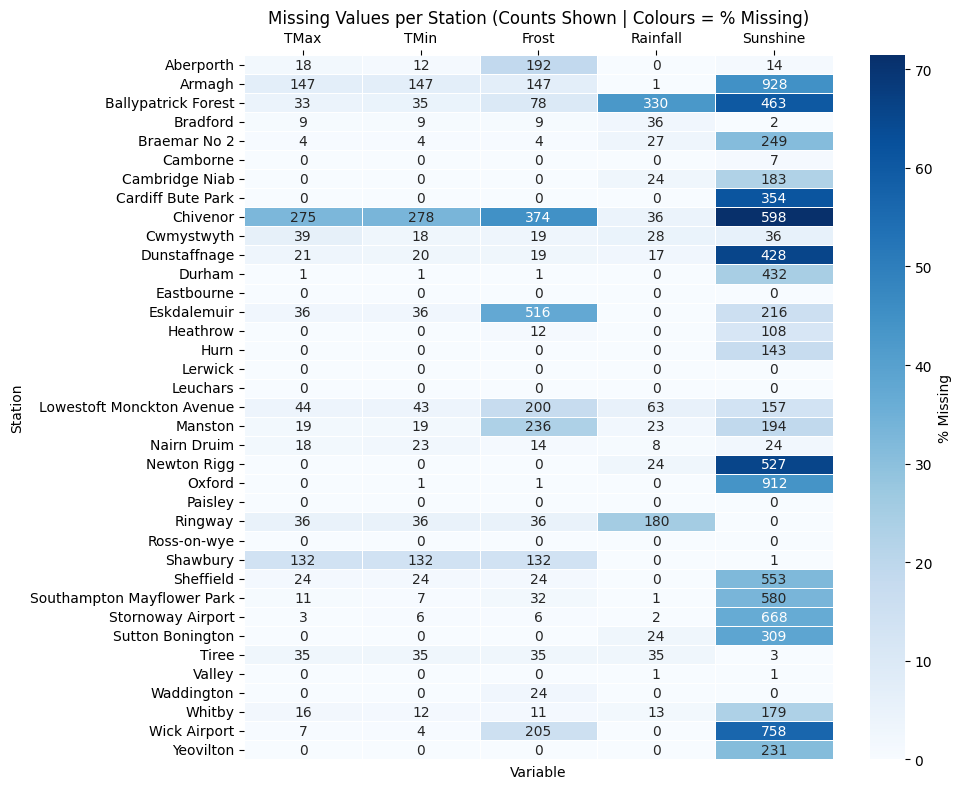

In [9]:
missing_counts_all = []
missing_percent_all = []

for station, df in weather_data.items(): 
    
    total = len(df)
    
    # Dict of missing counts for each station 
    missing_counts = {
        "Station": station,
        "TMax": df["TMax"].isna().sum(),
        "TMin": df["TMin"].isna().sum(),
        "Frost": df["Frost"].isna().sum(),
        "Rainfall": df["Rainfall"].isna().sum(),
        "Sunshine": df["Sunshine"].isna().sum()
    }
    # Percentage missing for heatmap colours 
    missing_percent = {k: (v/total)*100 if k!='Station' else station for k, v in missing_counts.items()}

    missing_counts_all.append(missing_counts)
    missing_percent_all.append(missing_percent)

missing_counts_df = pd.DataFrame(missing_counts_all).set_index('Station')
missing_percent_df = pd.DataFrame(missing_percent_all).set_index('Station')

# Plot heatmap of missing counts, with colour indicating percentage of readings missing 

plt.figure(figsize=(10,8))

sns.heatmap(
    missing_percent_df,
    annot=missing_counts_df,          
    fmt="d",                              # integer formatting
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={'label': '% Missing'},
    vmin=0, vmax=missing_percent_df.max().max()  # normalise colours
)

plt.title("Missing Values per Station (Counts Shown | Colours = % Missing)")
plt.xlabel("Variable")
plt.ylabel("Station")
plt.gca().xaxis.tick_top()
plt.tight_layout()
plt.show()





The heatmap illustrates that there are stations with missing readings for all of the weather data variables. Sunshine data is the most incomplete, with only 7 stations having complete data, and stations like Oxford and Chivenor missing close to 70% of values. TMax, TMin, Frost and Rainfall are largely complete: only a handful of stations have a high percentage of missing data for these variables. 

Stations with significantly incomplete data tend to have missing values across multiple variables, which is indicative of long periods of incomplete reporting (possibly temporary station closure), rather than isolated measurement inconsistencies. 

Overall, the heatmap suggests that Sunshine data require the most caution, whilst the other variables are significantly complete to be used in the analysis. 


Missing values will be handled differently throughout the report, depending on the nature of the analysis. For regression, dropping rows with missing values is appropriate because the dataset is large enough, and the missing count small enough, that omitting observations will not materially affect the fit of the model. In contrast, for a chi-squared test, dropping data may change the structure of the contingency tables, so missing values must be handled more carefully. The approach to handling missing values will be explained for each analysis. 

### 1.5 Variation in Station Operation Periods

Looking at trends, not raw data, so it is okay to use all available years of data. Choosing a time range during which all stations were operating would result in a large amount of the available data being omitted, which is not ideal. 

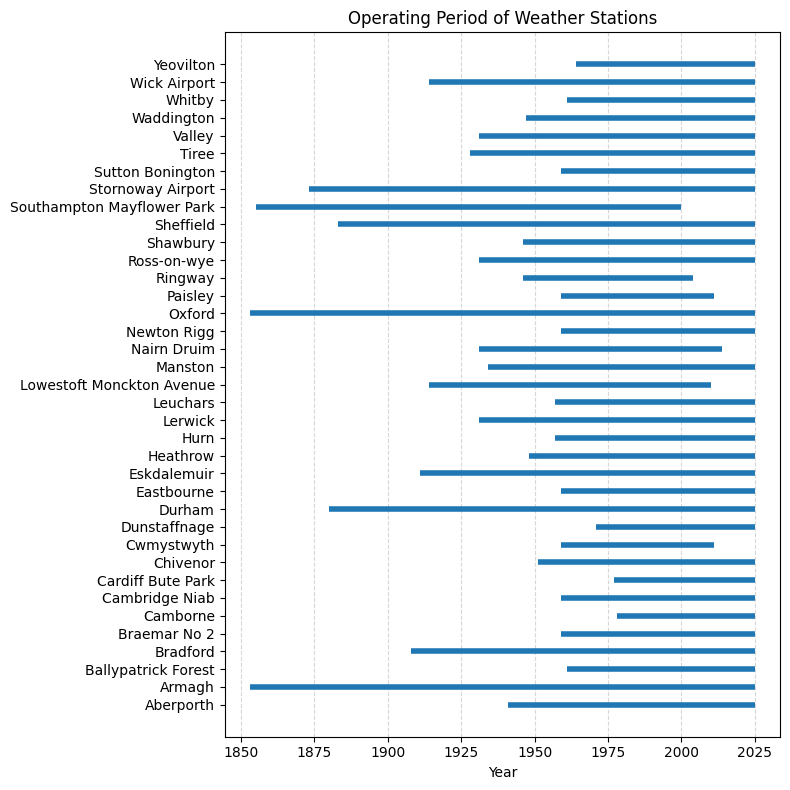

In [10]:
# Plot operating years for each station 

fig, ax = plt.subplots(figsize=(8,8))

y_positions = range(len(meta_df))

# Plot a bar for each station
for i, row in enumerate(meta_df.itertuples()):
    plt.hlines(
        y=i,
        xmin=row.Opened,
        xmax=row.Latest,
        linewidth=4
    )

# Formatting
plt.yticks(y_positions, meta_df['Name'])
plt.xlabel("Year")
plt.title("Operating Period of Weather Stations")
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The plots shows that the operating periods of the weather stations vary substantially, with some stations (e.g. Oxford and Armagh) providing over a century of observations, while others only opening in the latter half of the 20th century. Therefore, the time period over which weather observations were recorded varies between stations. 

For qualitative analysis, the variation in operating periods only affects how have back trends can be shown but for ........

## 2. Initial Evidence for Changing Climate

The first part of the analysis of the UK historic weather data is to examine the data for a small number of weather stations in diverse locations and present descriptive evidence for changing weather patterns over time. This gives an initial picture of any trends in the data and measurements to be investigated further. 

Trends in temperature, rainfall and frost days will be investigated. Due to the significant amount of missing sunshine data in the dataset, this variable will not be investigated.

### 2.1 Station Selection 

Two criteria were used to select the stations: 

1. Long operating period with few missing values  

    Stations with longer histories and few gaps in their data allow trends to be shown clearly, allow comparison of very different climatic periods (e.g. pre 1900 to modern day), and avoid any misleading conclusions that could be drawn by investigating data from recent decades. All of this is important when looking for meaningful, long-term patterns in weather data. 

2. Stations cover a diverse spread of UK climates and locations  

    Choosing a group of stations in diverse locations gives an insight into whether trends in weather records vary across the UK. 

The selected stations are: 

| **Station** | **Region**                | **Opening Year** | **Year of Latest Data** |
|:-----------:|:---------------------------|:-----------------:|:------------------------:|
| Oxford      | SE England, inland        | 1853             | 2025                    |
| Lerwick     | Scotland (Shetland Isles) | 1931             | 2025                    |
| Aberporth   | Wales, coastal            | 1941             | 2025                    |
| Armagh      | Northern Ireland          | 1853             | 2025                    |


Referring to the heatmap in the previous section, none of the chosen stations have a large proportion of missing values. 

For each variable, rows with missing values are dropped before plotting: a small number of missing months will not affect qualitative trends. Rolling averages are calculated on the remaining data using a 12-month window, which is unaffected by small gaps. Imputation of missing values is not required here. 

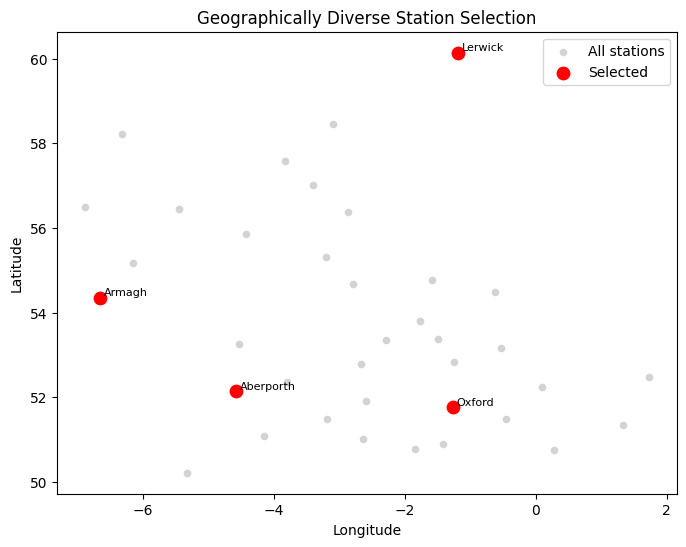

In [11]:
# Plot chosen stations on longitude against latitude axes

diverse_station_names = ['Oxford', 'Lerwick', 'Aberporth', 'Armagh']
diverse_stations_meta = meta_df.loc[meta_df.Name.isin(diverse_station_names)]

plt.figure(figsize=(8,6))
plt.scatter(meta_df['Longitude'], meta_df['Latitude'], color='lightgrey', label='All stations', s=20)
plt.scatter(diverse_stations_meta['Longitude'], diverse_stations_meta['Latitude'], color='red', label='Selected', s=80)
for i, row in diverse_stations_meta.iterrows():
    plt.text(row['Longitude'] + 0.05, row['Latitude'] + 0.05, row['Name'], fontsize=8)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographically Diverse Station Selection")
plt.legend()
plt.show()

In [12]:
# Create a new dictionary containing the weather data for the 4 selected stations
diverse_dfs = {}
for station in diverse_station_names:
    diverse_dfs[station] =  weather_data[station]

### 2.2 Maximum Temperature Trends

To explore long-term changes in temperatures, monthly TMax (the average of daily maximum temperatures) is plotted against time for each station, alongside a 12-month rolling mean. The rolling mean smooths out seasonal temperature cycles by averaging each point with the preceding 11 months. This makes underlying, long-term trends easier to identify. 

Before calculating the rolling mean, any records with missing TMax values are omitted; a small number of missing months does not impact the qualitative interpretation of long-term patterns. 

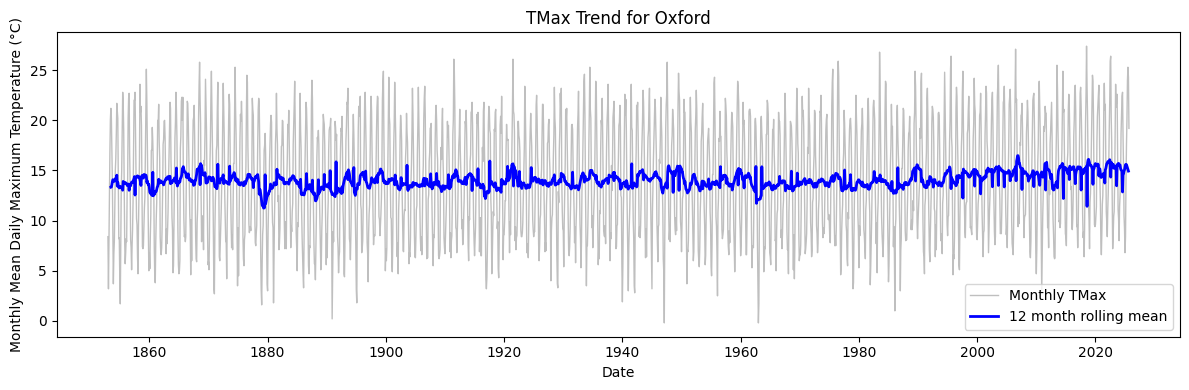

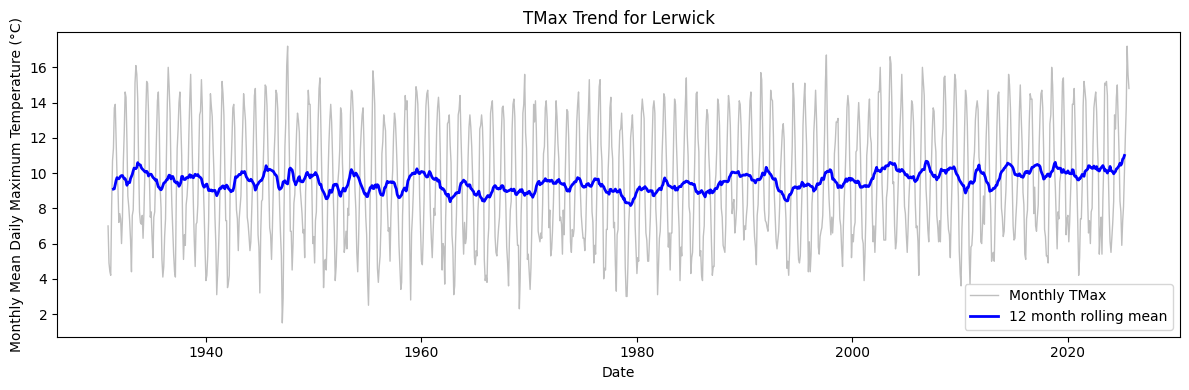

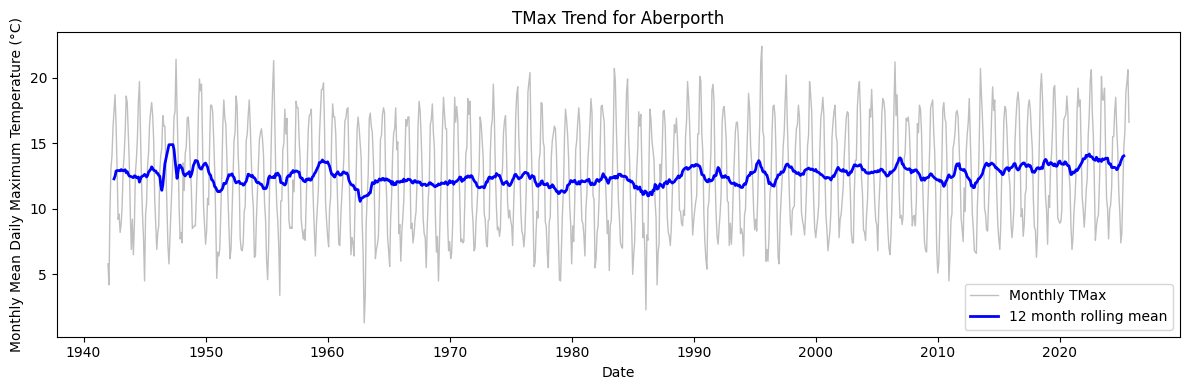

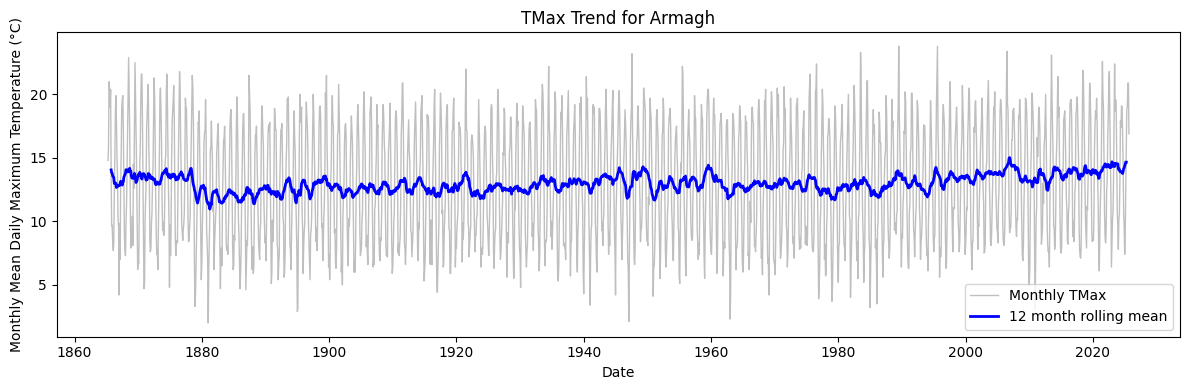

In [13]:
# Plots of TMax raw data with rolling 12 month average line

# Save df so can plot all 4 stations on one graph 
all_rows = []

for station, df in diverse_dfs.items():
    df = df.dropna(subset='TMax').copy()   # Drop missing TMax values

    df['TMax_roll'] = df['TMax'].rolling(window=12, center=True, min_periods=12).mean()   # Add yearly rolling averages 

    all_rows.append(df[['Date', 'TMax_roll', 'Station']])   # Save columns needed for combined rolling avg graph

    plt.figure(figsize=(12,4))

    # Plot light line for monthly values
    sns.lineplot(
        data=df,
        x='Date',
        y='TMax',
        color='grey',
        alpha=0.5,
        linewidth=1,
        label='Monthly TMax'
    )

    # Bold line for rolling mean 
    sns.lineplot(
        data=df,
        x='Date',
        y='TMax_roll',
        color='blue',
        linewidth=2,
        label='12 month rolling mean'
    )

    plt.title(f'TMax Trend for {station}')
    plt.xlabel("Date")
    plt.ylabel("Monthly Mean Daily Maximum Temperature (°C)")
    plt.tight_layout()
    plt.show()



Across all four stations, the monthly TMax values fluctuate in the expected seasonal cycle, with alternating summer peaks and winter troughs. The 12-month rolling mean smooths this variation and makes gradual long-term trends more visible. The rolling mean follows a similar shape for each of the stations: it is relatively stable in the mid 20th century but from around 1980 onwards, there is a gradual, though noticeable upward trend. This is consistent with global climate observations and the trend being observed across diverse locations in the UK provides qualitative evidence of increasing temperatures country-wide. 

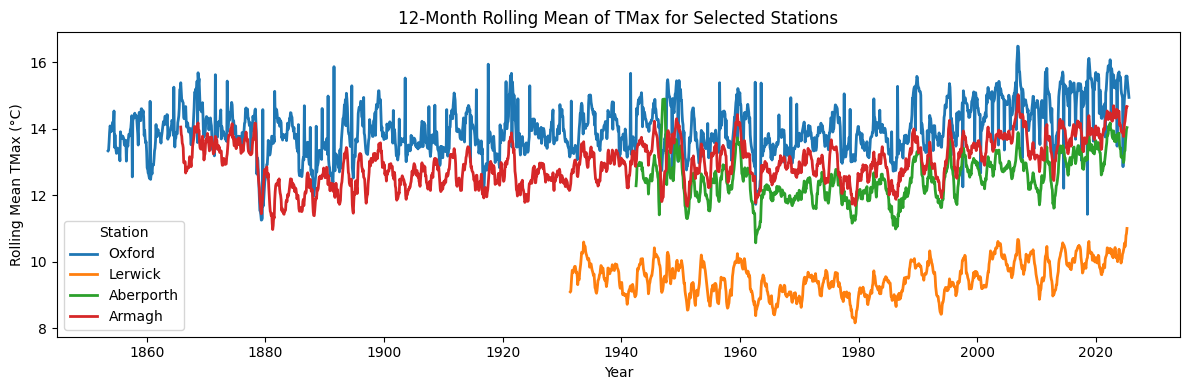

In [14]:
# Plot rolling average lines from all stations on one plot


combined_TMax_df = pd.concat(all_rows, ignore_index=True)


# Plot
plt.figure(figsize=(12, 4))

sns.lineplot(
    data=combined_TMax_df,
    x='Date',
    y='TMax_roll',
    hue='Station',
    linewidth=2
)

plt.title("12-Month Rolling Mean of TMax for Selected Stations")
plt.xlabel("Year")
plt.ylabel("Rolling Mean TMax (°C)")
plt.legend(title="Station")
plt.tight_layout()
plt.show()

A plot of the 12-month rolling mean of TMax for the four stations allows for easier comparison of temperature trends. Though beginning at different times, the shape of the rolling mean line for all 4 stations follows a similar shape from 1940 onwards: there is a clear upward trend for all of the stations. 

What is highlighted well by the plot is the regional variation in average temperatures across the UK: 
- Oxford shows the highest temperatures throughout, reflecting its inland, southern location. In recent decades, the rolling mean of TMax nears 16 degrees Celcius
- Lerwick has the lowest values, consistent with its far-northern maritime climate. Its TMax values are nearer to 10 degrees. 
- Aberporth and Armagh sit in the middle of the distribution. The marginally lower TMax values for Armagh could be attributed to its coastal location. Armagh may be more sheltered due to being inland. 

In summary, the upwards trend in TMax rolling averages indicates a shared underlying warming across the UK, while the variation in baseline temperatures demonstrates the differing regional climates found in the country. 

### 2.3 Rainfall Patterns

The a process similar to that used for temperature trends has been used to investigate changes in rainfall patterns with time. In place of TMax, the Rainfall column from the weather dataset is used. Each reading gives the total depth of water (in mm) that has accumulated over a flat surface in one month. Since annual fluctuation in rainfall can be much more erratic, the data is grouped by year and the total annual rainfall for each station is plotted against time, instead of the monthly readings. This representation significantly smooths the plots, highlighting any long-term changes.

As before, records with missing values are omitted, and in this case, a 5 year rolling average of rainfall is calculated. 

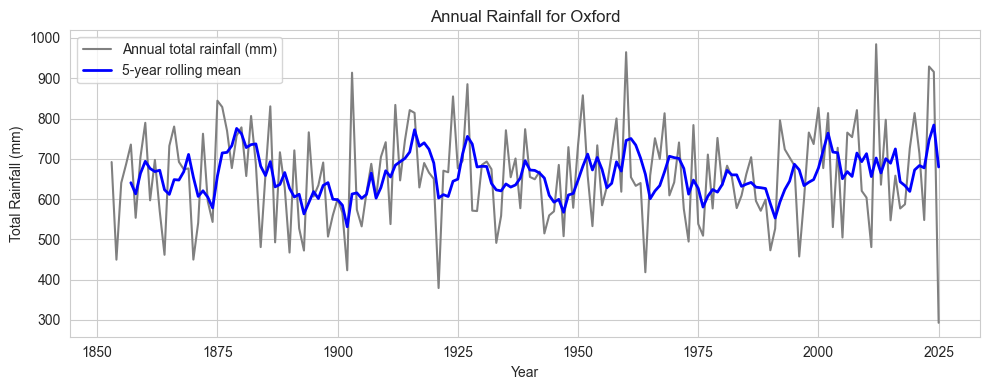

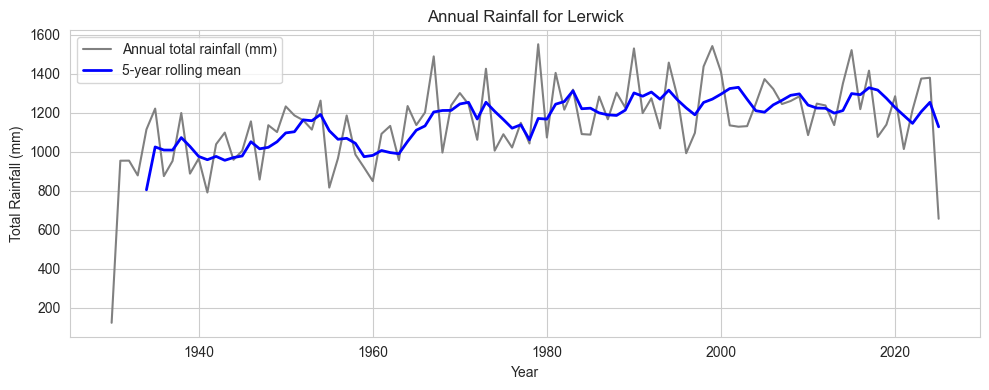

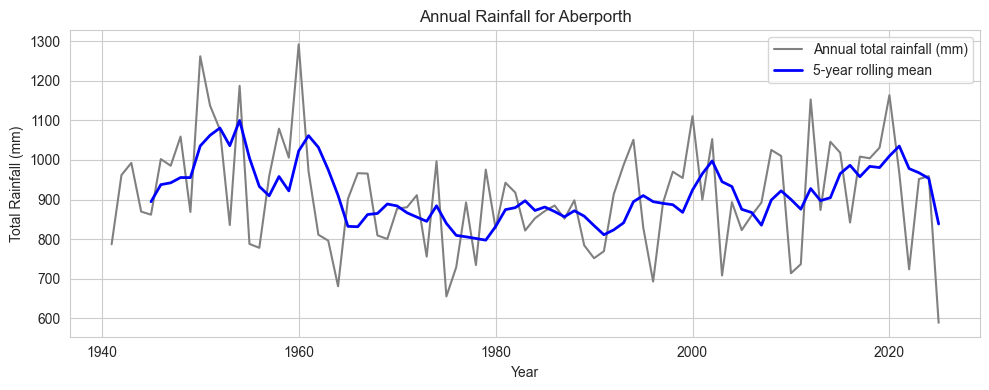

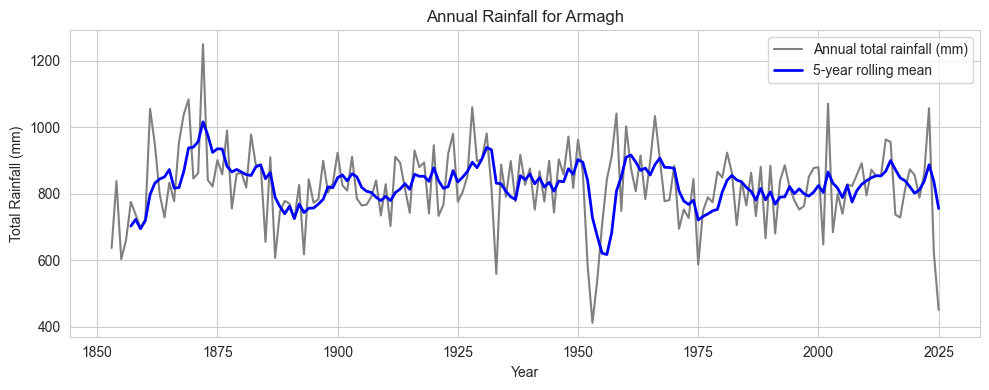

In [15]:
# Plots of rainfall raw data with rolling 12 month average line

# Save df so can plot all 4 stations on one graph 
all_rows = []

for station, df in diverse_dfs.items():
    df_annual = (
        df.dropna(subset='Rainfall').copy()
        .groupby('Year')['Rainfall']
        .sum()
        .reset_index()
    )

    # Add station name
    df_annual['Station'] = station

    # Create a Date column (use 1st Jan of each year)
    df_annual['Date'] = pd.to_datetime(df_annual['Year'].astype(str) + "-01-01")

    df_annual['Rain_roll'] = df_annual['Rainfall'].rolling(window=5, min_periods=5).mean()  # 5 year rolling mean
    all_rows.append(df_annual[['Date', 'Rain_roll', 'Station']]) 

    plt.figure(figsize=(10,4))
    sns.set_style("whitegrid")

    # Annual totals
    sns.lineplot(
        data=df_annual,
        x='Year',
        y='Rainfall',
        label='Annual total rainfall (mm)',
        color='grey',
        linewidth=1.5
    )

    # Rolling mean
    sns.lineplot(
        data=df_annual,
        x='Year',
        y='Rain_roll',
        label='5-year rolling mean',
        color='blue',
        linewidth=2
    )

    plt.title(f"Annual Rainfall for {station}")
    plt.ylabel("Total Rainfall (mm)")
    plt.xlabel("Year")
    plt.tight_layout()
    plt.show()



To further assist analysis, the 5-year rolling average lines for all of the stations have been plotted together, making variations between stations clearer to observe.

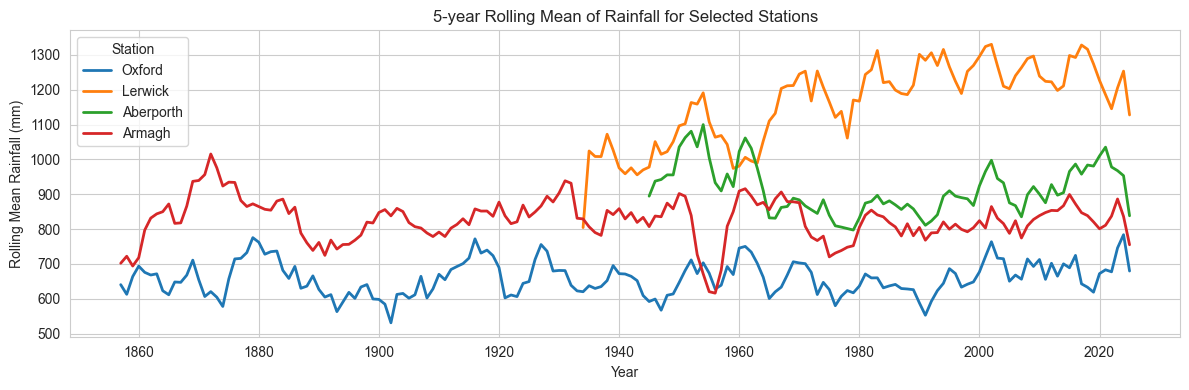

In [16]:
# Plot rolling average lines from all stations on one plot

combined_Rainfall_df = pd.concat(all_rows, ignore_index=True)


# Plot
plt.figure(figsize=(12, 4))

sns.lineplot(
    data=combined_Rainfall_df,
    x='Date',
    y='Rain_roll',
    hue='Station',
    linewidth=2
)

plt.title("5-year Rolling Mean of Rainfall for Selected Stations")
plt.xlabel("Year")
plt.ylabel("Rolling Mean Rainfall (mm)")
plt.legend(title="Station")
plt.tight_layout()
plt.show()

The annual total rainfall plots show strong year-on-year variation in precipitation, with some extremes corresponding to very wet or very dry years. The 5-year rolling average smooths out some of the yearly variation, showing longer term patterns. The following observations can be made from the plots: 

- There is no uniform trend - each station exhibit a different variation in rainfall levels over time. 
- Lerwick has the highest overall rainfall, with annual totals reaching almost double of observed levels in Oxford. This reflects its northern, maritime climate. It also displays an upward trend in rainfall from 1940 onwards. This could be indicative of the wetter winters that are expected with global warming: warmer air holding more moisture, 
- Aberporth displays significant fluctuation in rainfall, though there is no indication of a long-term upward or downward trend 
- Oxford and Armagh have relatively stable long-term behaviour, with rolling averages fluctuating around a central level. 

These regional differences highlight how rainfall patterns are more variable across the UK than temperature changes. A possible conclusion could be that coastal/maritime stations impacted more by rainfall increases resulting from increased temperature, while these effects are yet to be seen inland. The data does not indicate any UK-wide trends in rainfall. 

### 2.4 Frost Days

Frost recordings in the weather dataset give the number of days with air frost in a given month. Trends in the count of frost days over time could be indicative of wider changes in weather patterns, such as warmer winters. 

It is useful to first investigate the distribution of frost days across the months of the year across the four stations being investigated. The data for all four stations was combined into a single dataframe and the data was aggregated by month. 

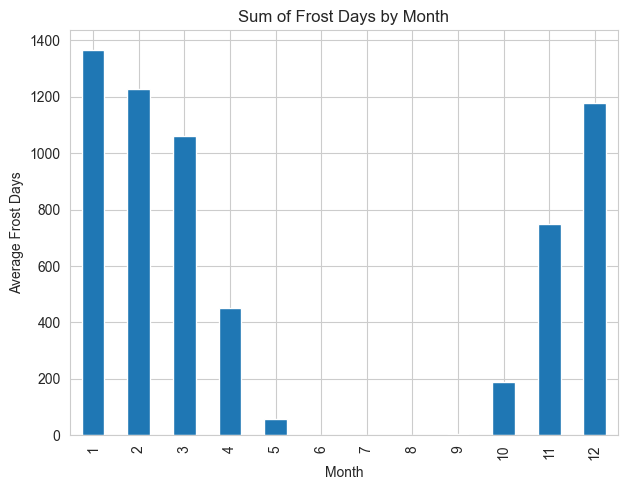

In [17]:
# Check distribution of frost days
all_rows = []

for station, df in diverse_dfs.items():
    all_rows.append(df[['Month', 'Year', 'Frost', 'Station']]) 

combined_frost_df = pd.concat(all_rows, ignore_index=True)

frost_by_month = combined_frost_df.groupby('Month')['Frost'].agg(['mean', 'sum', 'count'])

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df.groupby('Month')['Frost'].sum().plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Average Frost Days')
plt.title('Sum of Frost Days by Month')

plt.tight_layout()
plt.show()

The above plot shows that for all historic data recorded across the four stations, there have been no frost days in the months of June to August. Including frost data for these summer months would distort the plots by compressing the vertical scale, which makes trends harder to discern.  To provide a clearer view, frost days are aggregated to annual totals, before being plotted against time. After this, a rolling mean is calculated to further highlight long-term trends. 

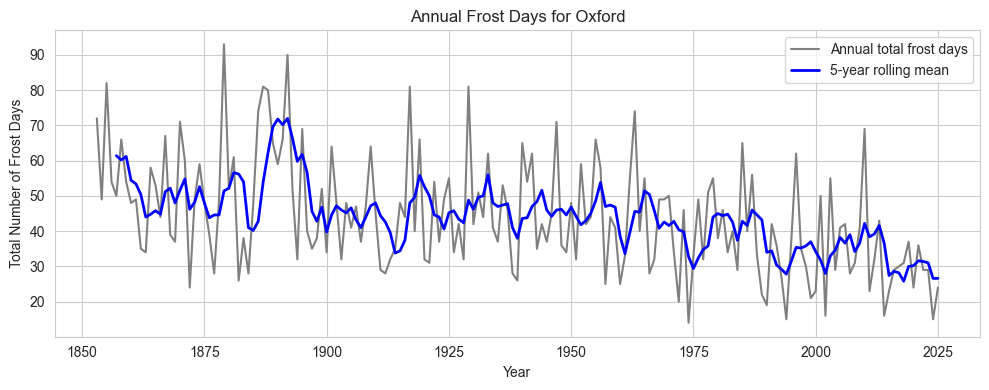

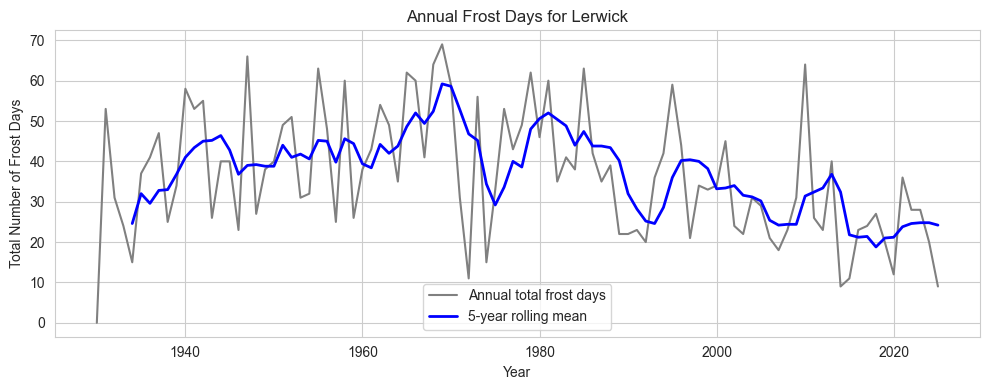

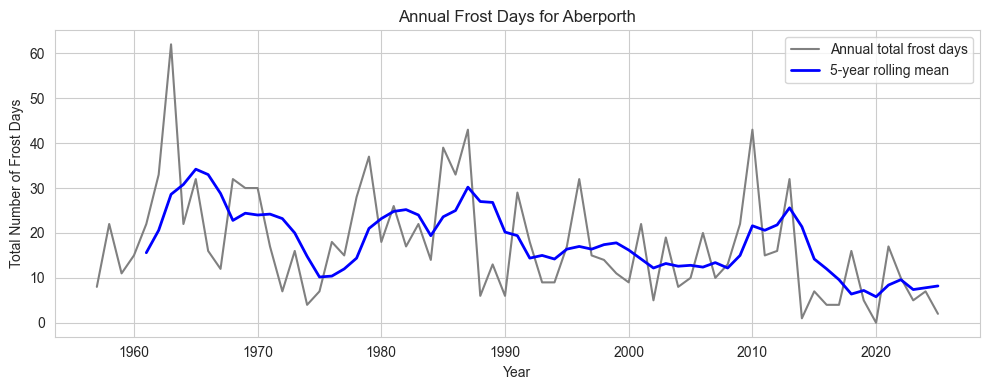

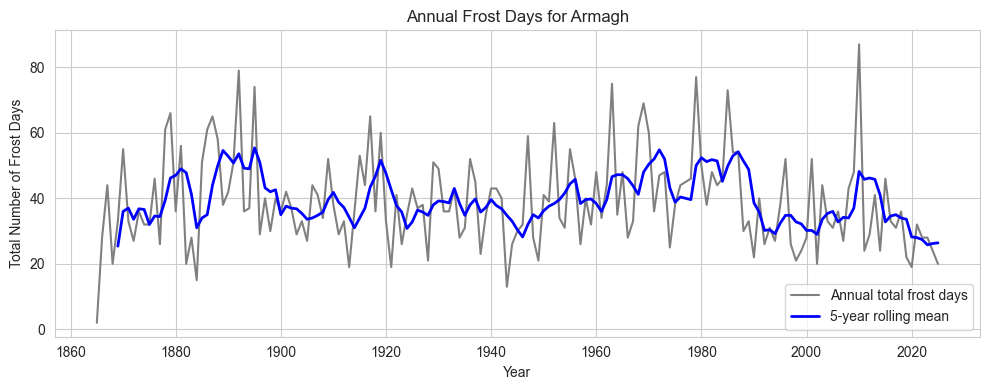

In [18]:
# Plots of rainfall raw data with rolling 12 month average line

# Save df so can plot all 4 stations on one graph 
all_rows = []

for station, df in diverse_dfs.items():
    df_annual_frost = (
        df.dropna(subset='Frost').copy()
        .groupby('Year')['Frost']
        .sum()
        .reset_index()
    )

    # Add station name
    df_annual_frost['Station'] = station

    # Create a Date column (use 1st Jan of each year)
    df_annual_frost['Date'] = pd.to_datetime(df_annual_frost['Year'].astype(str) + "-01-01")

    df_annual_frost['Frost_roll'] = df_annual_frost['Frost'].rolling(window=5, min_periods=5).mean()  # 5 year rolling mean
    all_rows.append(df_annual_frost[['Date', 'Frost_roll', 'Station']]) 

    plt.figure(figsize=(10,4))
    sns.set_style("whitegrid")

    # Annual totals
    sns.lineplot(
        data=df_annual_frost,
        x='Year',
        y='Frost',
        label='Annual total frost days',
        color='grey',
        linewidth=1.5
    )

    # Rolling mean
    sns.lineplot(
        data=df_annual_frost,
        x='Year',
        y='Frost_roll',
        label='5-year rolling mean',
        color='blue',
        linewidth=2
    )

    plt.title(f"Annual Frost Days for {station}")
    plt.ylabel("Total Number of Frost Days")
    plt.xlabel("Year")
    plt.tight_layout()
    plt.show()



For all four stations, the plots of number of frost days against time exhibit significant year-on-year fluctuation. This short-term fluctuation is expected, as frost frequency is strongly influenced by large-scale atmospheric circulation patterns. For example, certain winters could see prolonged periods of cold Arctic air, or, conversely, a flow of warm air. This leads to large natural swings in the frost days from one year to the next. 

However, after smoothing with a 5-year rolling mean line, all stations show evidence of a long-term decline in frost days, which is consistent with a warming climate that was observed in the TMax measurements. It is most pronounced for Oxford, where annual frost days have roughly halved from around 60 days in the late 19th century to roughly 30 in recent decades. Lerwick and Aberporth also show downward trends, though these are not as steep. The long-term change in frost days is weakest for Armagh, with frost days remaining fairly stable compared to other stations. 

These results provide qualitative evidence that annual frost days have decreased over time across much of the UK.

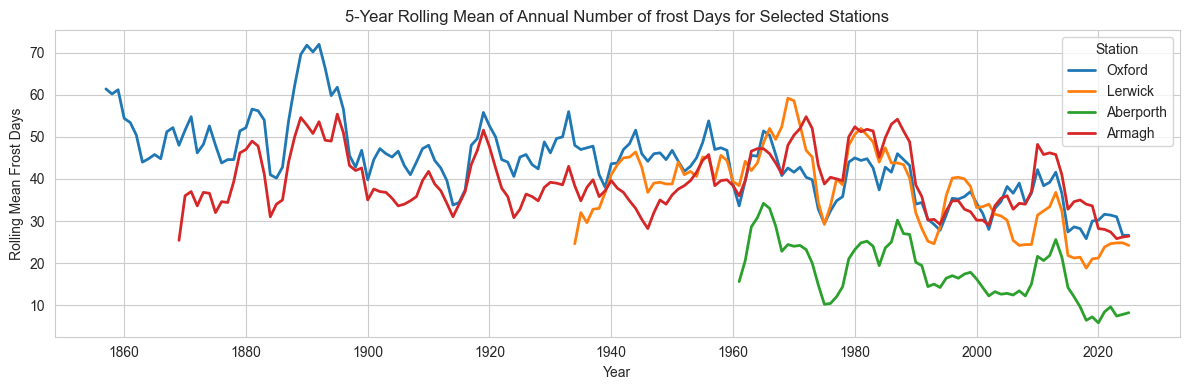

In [19]:
# Plot rolling average lines from all stations on one plot

combined_frost_df = pd.concat(all_rows, ignore_index=True)

# Plot
plt.figure(figsize=(12, 4))

sns.lineplot(
    data=combined_frost_df,
    x='Date',
    y='Frost_roll',
    hue='Station',
    linewidth=2
)

plt.title("5-Year Rolling Mean of Annual Number of frost Days for Selected Stations")
plt.xlabel("Year")
plt.ylabel("Rolling Mean Frost Days")
plt.legend(title="Station")
plt.tight_layout()
plt.show()

The downward trend in frost days can be clearly seen on the above plot, which shows the 5-year rolling mean for annual frost days for each of the stations. Here, the baseline for frost days in each region can be compared - Aberporth experiences noticeably fewer annual days of frost than the other three locations. Interestingly, Lerwick has a similar number of frost days to Aberporth and Armagh, despite its significantly lower maximum temperatures. 

### 2.5 Summary of Qualitative Evidence 

The descriptive analysis of temperature, rainfall, and frost days provides clear qualitative evidence of changing climate across the four selected UK stations. 12-month rolling TMax trends show a consistent long-term increase in temperature at all locations, with recent decades noticeably warmer than a century ago. Rainfall patterns are more variable: there is no distinct trend across stations, though the wetter weather in the maritime location, Lerwick, is of note. Frost days show the most distinct trend of the three variables investigated. Despite significant year-on-year fluctuations, most stations show a marked downward trend, particularly Oxford. Collectively, the observed trends in these variables provides evidence of a warming climate and reduced frost occurrence. This preliminary data exploration has also highlighted the variation in weather conditions and long-term trends between different regions in the UK.

## 3. Trend in Monthly Average of Daily Maximum Temperatures

The aim of this section is to investigate whether there is evidence for an increasing trend in daily maximum temperature averages (TMax). To do this, a linear regression is fitted for each station, using time as the predictor variable and TMax as the target, with addition sine and cosine terms to capture the seasonal temperature cycle. Residual bootstrap resampling is then used to estimate a confidence interval for the rate of temperature change at each station. By comparing the intervals across all 37 stations, the strength and geographical variation of warming trends can be assessed. Finally, for a selected subset of stations, a bootstrap predictive interval is calculated for TMax in August 2075, to give insight into potential future conditions.

### 3.1 Regression Approach

To model long-term changes in maximum temperature, a linear regression is fitted to the TMAx data for each station. 
As seen in the plots in section 2.2, temperature varies strongly with the seasons and does not follow a simple linear relationship with time. However, seasonality can be incorporated into the model by using harmonic sine and cosine terms, which allow the regression to capture the repeating yearly cycle. 

For the regression, a continuous time variable is required. during data preparation, a variable **t** was created by assigning January of the earliest year in the dataset the value 0, with each subsequent month in the dataset increasing this index by 1. Units of months were chosen for the time period as it is convenient for working with the monthly time resolution of the dataset.

The regression includes the harmonic terms $\cos(\omega t)$ and $\sin(\omega t)$, 
where $\omega = \frac{2\pi}{T}$. These terms capture the repeating seasonal cycle over the time period **T**, while keeping the model linear for the regression coefficients. In this case, **T** is a year (12 months). 

The resulting regression model takes the form:

$$
TMax_t = \beta_0 + \beta_1 t + \beta_2 \sin(\omega t) + \beta_3 \cos(\omega t) + \varepsilon_t
$$

Of particular interest is the coefficient $\beta_1$, the rate of temperature (TMax) change over time. A positive value corresponds to increasing average temperature over time, negative values indicate a decreasing trend, and a value close to zero indicates little or no trend. 

### 3.2 Fitting the Regression

For each of the 37 stations, the linear regression model described in section 3.1 is fitted to the monthly TMax data. The fitted model, predicted values, and residuals for each station are stored in a dictionary, allowing for comparison of the regression fit across stations. 

**Handling missing TMax values**   

Before fitting the regression to the data, any records with missing TMax data will be omitted: 
- Sci-kit learn cannot handle NaN values when fitting a linear regression
- Each weather station dataset has at least hundreds of monthly data points, so removing a small number of missing observations from a large dataset wil have a negligible affect the fit of the model. Imputation is not necessary here. 

The fitted values and residuals produced by each regression are then examined to assess how well the model captures both the long-term trend in the data.

In [20]:
# Define function to fit regression with dataframe provided
def doRegression(df): 
    y = df.TMax
    X = np.column_stack([df['t'], df['sin(wt)'], df['cos(wt)']])

    reg = LinearRegression().fit(X,y)
    y_hat = reg.predict(X)
    residuals = y - y_hat
    rmse = root_mean_squared_error(y, y_hat)

    return reg, X, y_hat, residuals

In [21]:
# Loop through all 37 stations and store regression results in a dictionary 

reg_results = {}

for station, df in weather_data.items():
    df = df.dropna(subset='TMax').loc[:,['Date', 't', 'sin(wt)', 'cos(wt)', 'TMax', 'Year', 'Month']]   # Drop records with missing TMax

    reg, X, y_hat, residuals = doRegression(df)

    reg_results[station] = {
        'reg': reg,
        "X": X,
        'y': df.TMax.values, 
        'y_hat': y_hat,
        'residuals': residuals, 
        'R2': reg.score(X, df.TMax),
        'rmse': root_mean_squared_error(df.TMax, y_hat),
        'beta1': reg.coef_[0],
        'df': df
    }


In [22]:
# Create dataframe of regression results for all stations
reg_results_df = pd.DataFrame.from_dict(reg_results, orient='index')
reg_results_df.index.name = 'Station'
reg_results_df.reset_index(inplace=True)

#### 3.2.1 Overview of Quality of Regression Fit Across All 37 Stations

To get an indication of the quality of the linear regression fit across all stations, summary plots of **R<sup>2</sup>** and **root mean squared error (RMSE)** values across the stations are produced. 

**R<sup>2</sup>** (coefficient of determination) measures the proportion of the variance in the target variable, TMax, that is explained by the regression model (variation in time). A value close to one indicates that the model explains all of the variance; a higher R<sup>2</sup> indicates a better fitting model. 

The distribution of the R<sup>2</sup> values from the regression models for all stations is shown in the below histogram. 


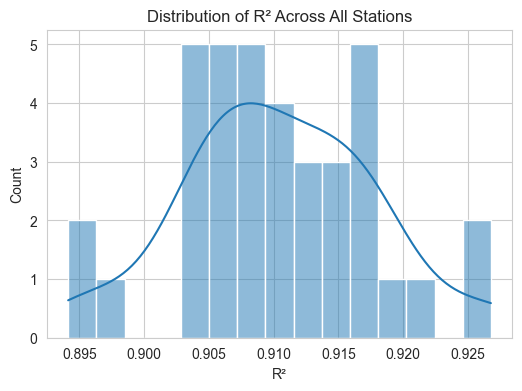

In [23]:
# R squared distribution across stations 

plt.figure(figsize=(6,4))
sns.histplot(reg_results_df["R2"], bins=15, kde=True)
plt.title("Distribution of R² Across All Stations")
plt.xlabel("R²")
plt.show()


The plot shows that R<sup>2</sup> values across the stations vary from approximately 0.89 to 0.93. Values for all stations being close to one indicates that the regression model explains variance in the maximum temperature data very well. Only a small amount of the variance is due to other factors not accounted for by the model (e.g. weather uncertainty, local geographical effects). 

**RMSE** provides an absolute measure of the average prediction error in TMax values predicted by the regression model. Lower RMSE values indicate a better fit. 
The distribution of RMSE values across the 37 stations is plotted below. 

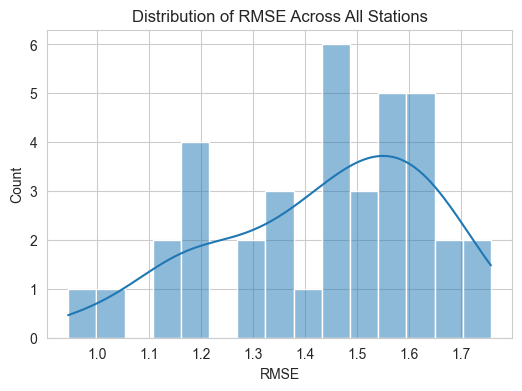

In [24]:
# RMSE distribution across stations 

# R squared across stations 

plt.figure(figsize=(6,4))
sns.histplot(reg_results_df["rmse"], bins=15, kde=True)
plt.title("Distribution of RMSE Across All Stations")
plt.xlabel("RMSE")
plt.show()


The distribution of RMSE values across the stations ranges from approximately 0.95 to 1.75 degrees Celsius. These values indicate that the model performs well when reproducing monthly maximum temperature trends, especially when considering that month-on-month temperature variations can be as large as 5-10 degrees. The relatively small spread of the values suggest that the model performs well across all UK stations, regardless of station geography or climate. 

Stations with higher RMSE values likely experience greater short-term variability in maximum temperature (e.g. exposed coastal or high altitude locations), meaning that the long term trend and seasonal variation is captured by the terms in the regression model, but some more extreme local variability is unexplained. 

Patterns in RMSE values can be further explored by visualising them geographically. 

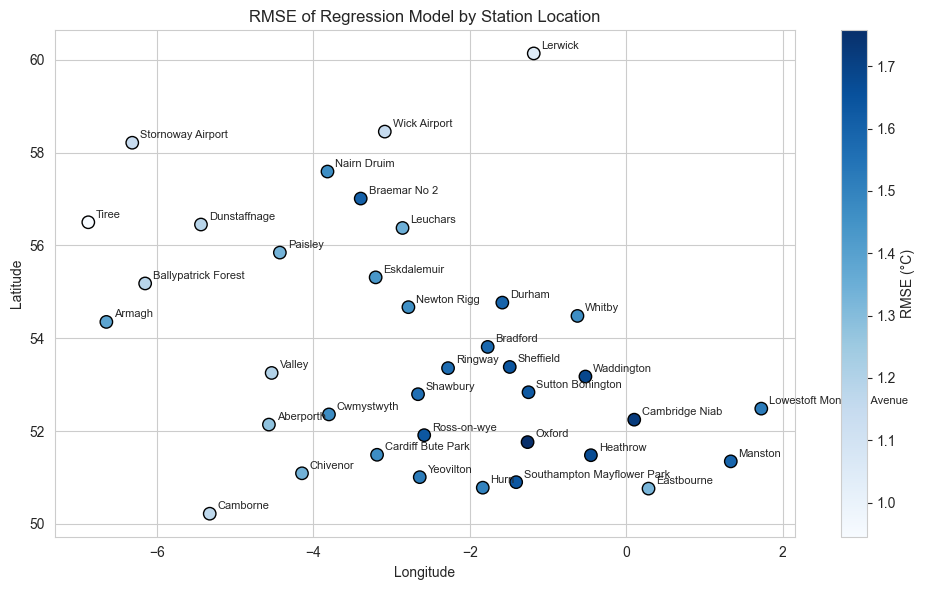

In [25]:
# Merge RMSE results into metadata so we have lat, lon, RMSE together
rmse_geo = meta_df.merge(
    reg_results_df[['Station', 'rmse']],
    left_on='Name',
    right_on='Station',
    how='inner'
)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

scatter = plt.scatter(
    rmse_geo['Longitude'],
    rmse_geo['Latitude'],
    c=rmse_geo['rmse'],
    cmap='Blues',
    s=80,
    edgecolor='black'
)

plt.colorbar(scatter, label="RMSE (°C)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("RMSE of Regression Model by Station Location")

# Label stations
for _, row in rmse_geo.iterrows():
    plt.text(
        row['Longitude'] + 0.1,
        row['Latitude'] + 0.1,
        row['Station'],
        fontsize=8
    )

plt.tight_layout()
plt.show()


The RMSE values show a clear geographical pattern when stations are plotted on longitude and latitude axes. The stations with the highest values are concentrated in the South and East of England (e.g. Cambridge, Oxford, and Heathrow). These stations have RMSE values close to 1.7 degrees Celsius. By contrast, many northern and coastal stations have lower values, generally below 1.2 degrees. 

This suggests that the harmonic regression terms fit the temperature data slightly less well in te southeast than in more exposed, northern, coastal climates. It is possible that more southerly, inland stations experience less stable seasonal weather patterns, that are less easily predicted by a regression model. Despite spatial variations, the model still performs well across all regions. 

Overall, the regression model provides a consistently strong fit across all 37 weather stations: 
- R<sup>2</sup> values are unifromly high (0.89-0.93)
- RMSE values are low (around 1-1.75 degrees C)
- No station exhibits an unusually poor fit

#### 3.2.2 In-Depth Examination of Regression Fit for Selected Stations  

While the regression model fits well overall, a deeper inspection of the fit of the model for a small number of stations is useful. They can be assessed for how well the modelling assumptions of linear regression hold, for example, whether residuals appear to be normally distributed. 

The geographically diverse stations used in section 1 will be used again, in order to get further a view on whether regression fit varies across the UK. 
These are: 
- Oxford
- Lerwick 
- Aberporth
- Armagh


**Distribution of Residuals**

The performance of the regression model can be assessed using the residuals (errors) - these are the differences between the predicted and actual values of the target variable, TMax.

For a linear regression, a key assumption is that the residuals are normally distributed. If this is not the case, metrics for the error of the model may not be as accurate. for each of the 4 stations, a histogram of the residuals for the station's model is plotted. 

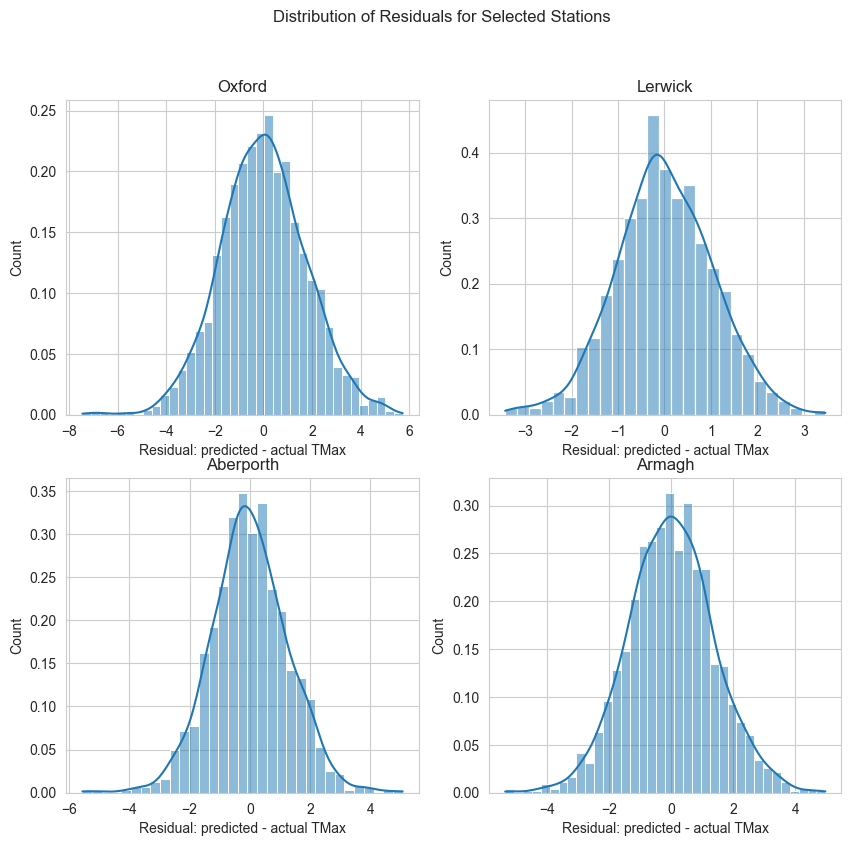

In [26]:
# Predicted values and errors

fig, axes = plt.subplots(2,2, figsize=(10,9))
axes = axes.flatten()   # to make indexing easier

for i, station in enumerate(diverse_station_names):
    ax = axes[i]
    residuals = reg_results[station]['residuals']
    sns.histplot(data=residuals, stat='density', kde=True, ax=ax)
    ax.set_xlabel('Residual: predicted - actual TMax')
    ax.set_ylabel('Count')
    ax.set_title(f'{station}')

plt.suptitle('Distribution of Residuals for Selected Stations')
plt.tight_layout
plt.show()



For all 4 stations, the distribution of residuals appears to be close to normal: they are fairly symmetric, with small tails. this indicates that the assumptions of the regression model are likely valid and that it is a good fit for the data. This is positive as it makes significance testing more reliable. 

**Predicted vs Actual Values**

Another way to assess how well the model fits is by plotting actual target variable values against their predicted values. This provides a simple visual check of the overall model fit. If the regression captures he underlying structure well, the points should lie close to a 45 degree line. Excessive scatter suggests a high level of unexplained variability. These plots, alongside the histograms of residuals, help to confirm that the harmonic regression adequately models TMax variation. 

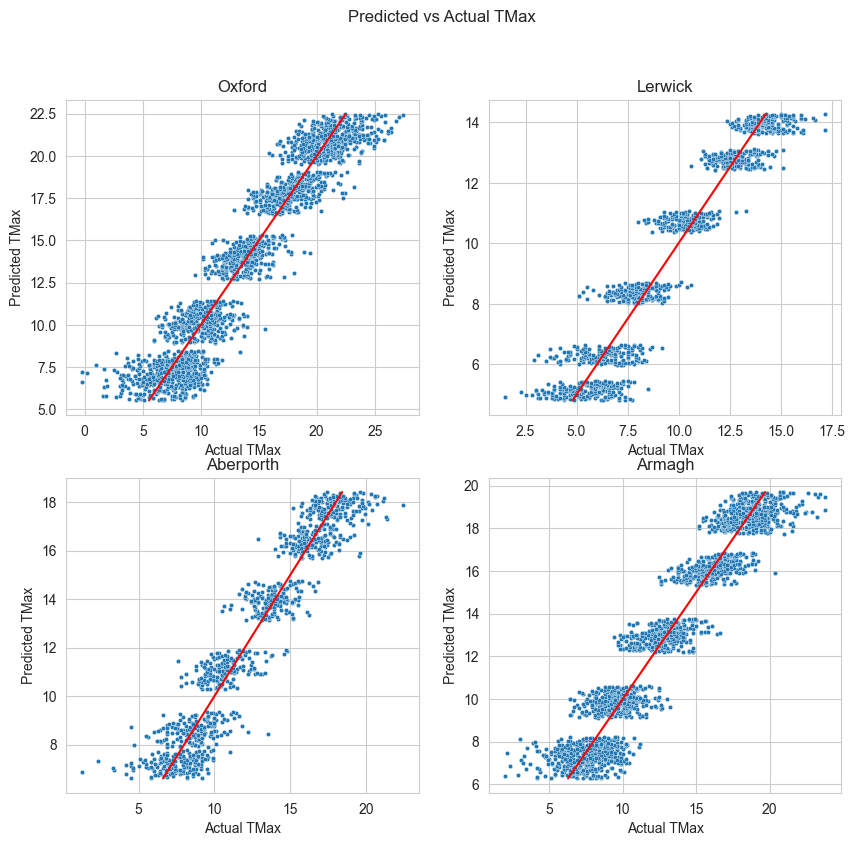

In [27]:
# Plot scatter of actual vs pred

fig, axes = plt.subplots(2,2, figsize=(10,9))
axes = axes.flatten()   # to make indexing easier

for i, station in enumerate(diverse_station_names):
    ax = axes[i]
    y = reg_results[station]['y']
    y_hat = reg_results[station]['y_hat']
    sns.scatterplot(x=y, y=y_hat, s=10, ax=ax)
    sns.lineplot(x=y_hat, y=y_hat, color='red', ax=ax)
    ax.set_xlabel('Actual TMax')
    ax.set_ylabel('Predicted TMax')
    ax.set_title(station)

plt.suptitle('Predicted vs Actual TMax')
plt.tight_layout
plt.show()


While the spread of values about the perfect fit line varies slightly between stations, all four of the scatter plots exhibit a strong linear relationship. This indicates that the regression model is capturing the structure in the temperature data well. 
- Points are clustered about the 45 degree reference line: predicted temperatures closes matched observed temperatures. 
- The data points are clearly clustered around seasonal bands. 
- There is greater deviation from the reference line for extreme high/low temperatures. this is to be expected - the model accounts for average harmonic cycles, not monthly extremes. 

The plots further confirm the good fit of the model across stations.

### 3.3 Confidence Intervals for Rate of Temperature Change

The previous section established that the regression model fits well across all stations in the dataset. The next part of the analysis is to quantify the long-term change in average temperature at each station. 

The coefficient of interest is $\beta_1$, which represents the long-term rate of change in the average maximum daily temperature (change in TMax per month). While the fitted regression model gives a singular value of $\beta_1$ per station that indicates whether there is a warming or cooling trend, it does not provide information on the precision of the estimate. 

To quantify the uncertainty in the estimate, **bootstrap resampling of residuals** is used to obtain **confidence intervals** for $\beta_1$ at each station. this approach provides a robust measure of uncertainty in $\beta_1$ values. Confidence intervals help to determine whether warming trends are statistically significant and allows for comparison of strength of warming trends and uncertainty in trends across stations. 

#### 3.3.1 Bootstrap procedure 

The bootstrap is a resampling method that uses the existing dataset to approximate the sampling distribution of a test statistic - in this case, the temperature trend coefficient, $\beta_1$. Instead of repeatedly sampling new datasets from the population (which is impossible), the bootstrap generates new datasets by resampling the residuals from the fitted regression model.

For each station,  the regression model is fitted and the predicted TMax values and residuals are obtained. To generate a bootstrap sample, the residuals are **resampled with replacement** and added back to the predicted values, producing a new, bootstrapped TMax series that incorporates realistic random variation that you would expect within the population.The regression is then refitted to this botstrapped dataset to obtain a bootstrapped estimate of $\beta_1$.

This procedure is repeated many times, producing an empirical distribution of bootstrap estimates of the temperature trend coefficient. This empirical distribution approximates the true sampling distribution of $\beta_1$ and quantile-based confidence intervals can be calculated directly from it. These intervals provide a robust measure of the amount of uncertainty in the estimated temperature trend for the individual weather stations. 

For this analysis, resampling of residuals with replacement is performed **500** times. This number is sufficient to produce reliable confidence intervals for $\beta_1$, while not using excessive computation resource. 


In [28]:
# Bootstrap for CIs


B = 500 # Number of bootstrap samples - start with this because that's what he's used in the notebook 

# 2 - function that carriers out bootstrap on residuals
def bootstrap_resid(station, repeats=B):

    reg = reg_results[station]['reg']
    X = reg_results[station]['X']
    y_hat = reg_results[station]['y_hat']
    residuals = reg_results[station]['residuals']

    # Save the time trend coefficient from the original regression
    beta1_hat = reg_results[station]['beta1']

    # Produce empty dataframe to store bootstrap results
    # Columns are sample statistics
    # Each row corresponds to 1 bootstrap resample
    bootstrap_coef = pd.DataFrame(
        np.empty((repeats, X.shape[1] + 1)), # number of predictors plus 1 for intercept)
        columns=['beta_B0', 'beta_B1', 'beta_B2', 'beta_B3']
    )

    for i in range (0, repeats):
        resampled_resid = resample(residuals, replace=True) # Get a bootstrap sample of residuals using resample and populate df with result

        y_boot = y_hat + resampled_resid

        reg_boot = LinearRegression().fit(X, y_boot)

        bootstrap_coef.iloc[i, 0] = reg_boot.intercept_
        bootstrap_coef.iloc[i,1:] = reg_boot.coef_


        # Calculate confidence intervals (for 95%)
        ci_low = bootstrap_coef.beta_B1.quantile(0.025)
        ci_high = bootstrap_coef.beta_B1.quantile(0.975)
    
    return bootstrap_coef, beta1_hat, ci_low, ci_high



In [29]:
# Loop through al stations 
bootstrap_results = []

for station, results in reg_results.items():

    df = reg_results[station]['df']

    bootstrap_coef, beta1_hat, ci_low, ci_high = bootstrap_resid(station)

    bootstrap_results.append({
        'Station': station,
        'Bootstrap coefs': bootstrap_coef,
        'Beta1_estimate': beta1_hat,
        'CI_low': ci_low,
        'CI_high': ci_high
    })

# Create dataframe of bootstrap results
bootstrap_df = pd.DataFrame(bootstrap_results)

# Convert units to per year - easier to interpret 

bootstrap_df["Beta1_estimate"] = 12 * bootstrap_df["Beta1_estimate"]
bootstrap_df["CI_low"] = 12 * bootstrap_df["CI_low"]
bootstrap_df["CI_high"] = 12 * bootstrap_df["CI_high"]


#### 3.3.2 Distribution of Bootstrapped $\beta_1$ Estimates

Before looking at confidence intervals across all stations, it is useful to inspect more closely the bootstrapped distribution of the regression coefficient $\beta_1$ for a small number of stations. Oxford and Lerwick, from the subset of stations that has been used throughout the analysis, are used here. 

The plots below show a histogram of the bootstrapped values for $\beta_1$, the coefficient that describes the rate of change of TMax over time. The red dashed line shows the estimate of the coefficient that was produced by the original linear regression, and the black dotted lines mark the boundaries of the **95% confidence interval** for $\beta_1$. 

A 95% confidence interval is used for this analysis because it is the standard level used for statistical inference. It is a wide enough interval that it reflects genuine uncertainty in the value of $\beta_1$, while still enabling meaningful conclusions to be made about whether a rate of temperature increase is statistically supported by the data. 

In the context of this analysis, a 95% confidence interval means that if the whole sampling process were repeated many times, 95% of the confidence intervals produced for $\beta_1$ would contain the true value of $\beta_1$ (i.e. the true rate of change of TMax with time). If a station's confidence interval does not include zero, it can reasonably be concluded that the warming trend is not due to random variation alone. 

For ease of interpretation, the units for regression coefficients and confidence intervals have been converted from degrees Celsius per month to degress Celsius per year.

Lerwick:
95% confidence interval for beta_1, the is 0.00443 to 0.00879. Beta 1 is the estimated rate of change of max temp in degrees Celsius per year 

Oxford:
95% confidence interval for beta_1, the is 0.00836 to 0.01140. Beta 1 is the estimated rate of change of max temp in degrees Celsius per year 



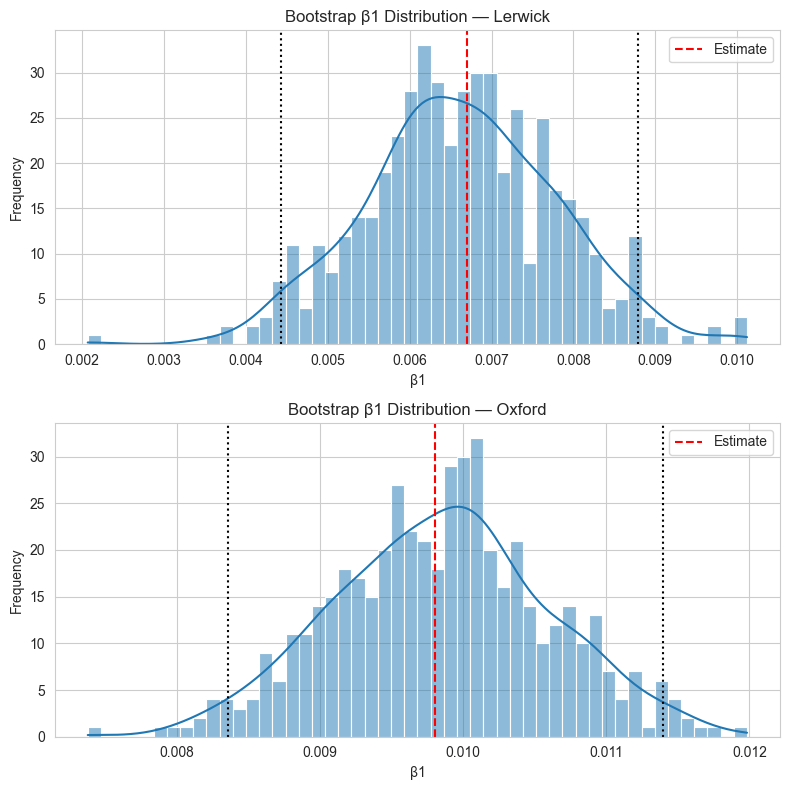

In [30]:
stations = ['Oxford', 'Lerwick']
subset = bootstrap_df[bootstrap_df["Station"].isin(stations)]


fig, axes = plt.subplots(2, 1, figsize=(8,8))
axes = axes.flatten()

for i, (idx, row) in enumerate(subset.iterrows()):
    ax = axes[i]
    betas = row["Bootstrap coefs"].beta_B1  * 12        # convert to per year, easier to understand
    sns.histplot(betas, kde=True, bins=50, ax=ax)
    ax.axvline(row["Beta1_estimate"], color='red', linestyle='--', label='Estimate')    # add line for beta1 original estimae
    ax.axvline(row["CI_low"], color='black', linestyle=':') #Lines for 95% CI
    ax.axvline(row["CI_high"], color='black', linestyle=':')

    ax.set_title(f"Bootstrap β1 Distribution — {row['Station']}")
    ax.set_xlabel("β1")
    ax.set_ylabel("Frequency")
    ax.legend()

    print(f'{row['Station']}:')
    print('95%% confidence interval for beta_1, the is %4.5f to %4.5f. Beta 1 is the estimated rate of change of max temp in degrees Celsius per year \n' % 
      (row["CI_low"], row["CI_high"]))

plt.tight_layout()
plt.show()


For Lerwick and Oxford, the bootstrap distributions of $\beta_1$ (the rate of change of TMax per year) are centred around positive values. This suggests that there is strong evidence of long-term warming at both stations. 

Lerwick 
- Approximately symmetric, smooth distribution
- $\beta_1$ of approximately **0.007 degress C per year**
- 95% CI of roughly **0.0044 to 0.0094 degress C per year**. The entire interval is above zero, meaning that Lerwick shows a statistically significant positive rate of change of temperature.

Oxford
- Also smooth and approximately normal, but narrower than Lerwick's. Narrower distribution indicates less variance and less uncertainty in the estimate of $\beta_1$. 
- $\beta_1$ of approximately **0.010 degress C per year**. This is higher than Lerwick, which is consistent with what is expected for inland Southern england compared with a far north, maritime location, 
- 95% CI of roughly **0.0082 to 0.0114 degress C per year**. Oxford also shows a statistically significant warming trend, ad a stronger one than Lerwick. 

Overall, Oxford shows a stronger and more certain warming trend than Lerwick, but both stations have a statistically significant warming trend, i.e. the increase in TMax with time is not due to random chance.

NB: The values for confidence intervals quoted in this analysis are not the noly possible values. The bootstrapped distributions of the regression coefficient have been produced by **random resampling with replacement**, so each time this is run, a different set of values will be produced. They will be similar to the ones seen here, but not exactly the same. 


#### 3.3.3 Confidence Intervals for All Stations

Now that the bootstrap distribution for the test statistic have been examined for a couple of stations, the 95% confidence intervals for the rate of temperature change for all 37 stations will now be compared. 

The 95% bootstrap confidence intervals for $\beta_1$ across all 37 stations are shown in the plot below. Stations are ordered by the length of time they have operated for. Circular markers represent the $\beta_1$ estimate produced by the original regression for each station and the horizontal lines represent the confidence interval.


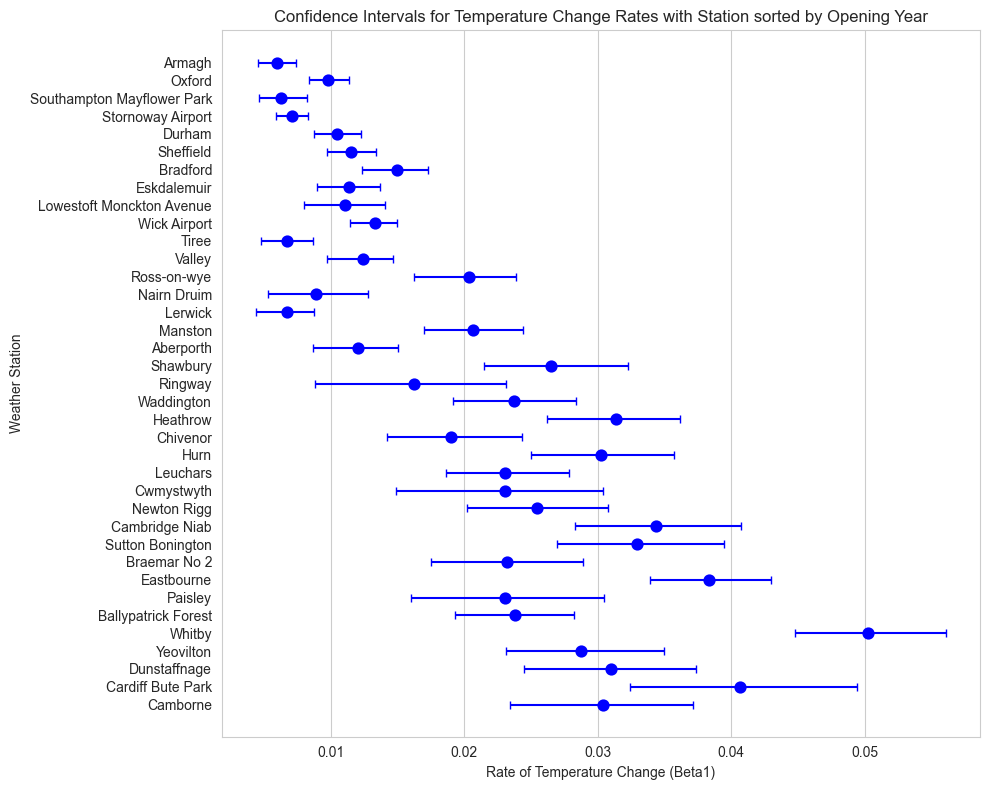

In [31]:
# Now plot CIs per station - need to look for patterns, e.g. location 

# Calculate error bars for seaborn (difference from estimate)
bootstrap_df["yerr_low"] = bootstrap_df["Beta1_estimate"] - bootstrap_df["CI_low"]
bootstrap_df["yerr_high"] = bootstrap_df["CI_high"] - bootstrap_df["Beta1_estimate"]

# Merge opening-year information into bootstrap_df
bootstrap_df = bootstrap_df.merge(
    meta_df[['Name', 'Opened']],
    left_on='Station',
    right_on='Name',
    how='left'
)
bootstrap_df_sorted = bootstrap_df.sort_values(by='Opened', ascending=True)

plt.figure(figsize=(10, 8))
sns.pointplot(
    data=bootstrap_df_sorted,
    x="Beta1_estimate",
    y="Station",
    color='blue',
    linestyles="none",
    errorbar=None   #  add error bars manually
)

plt.errorbar(
    x=bootstrap_df["Beta1_estimate"],
    y=bootstrap_df["Station"],
    xerr=[bootstrap_df["yerr_low"], bootstrap_df["yerr_high"]],
    fmt='none',
    ecolor='blue',
    capsize=3
)

plt.xlabel("Rate of Temperature Change (Beta1)")
plt.ylabel("Weather Station")
plt.title("Confidence Intervals for Temperature Change Rates with Station sorted by Opening Year")
plt.tight_layout()
plt.show()


The plot shows that the confidence for all 37 weather stations fall over positive values of TMax and no confidence intervals cross zero. this suggests that every station in the dataset exhibits a long-term increase in maximum temperature. 

The estimated warming rates vary across stations:
- Most stations lie between 0.01 and 0.03 degrees per year, corresponding to 1 to 3 degrees Celsius per century. 
- Some stations have greater rates of changing temperature, around 0.04 and 0.05 degrees Celsius per year, respectively. 
- The magnitude of the rate of temperature increase increases as station open years become more recent. This is expected: stations opened in the mid 19th century, such as Oxford and Armagh, capture data on cooler decades observed before the late 20th century. this cooler baseline means that the rate of change of temperature is less steep when averaged over the last 180 years. In contrast, newer stations will primarily capture data on the rapid warming observed from the 1980s onwards, giving rise to a steeper regression trend. 

The widths of confidence intervals also vary across stations, from approximately 0.003 to almost 0.02 degrees Celsius per year. This corresponds to differing levels of uncertainty in the reported rates of temperature change. Again, a pattern relating to station opening year is observed: the range of the 95% confidence interval increases as opening year becomes more recent. That is, there is more uncertainty and more sampling variability for more recently opened stations. This reflects the reduced information captured by the regression on a smaller dataset. There is more sensitivity to short-term trends, resulting in more variance in the distribution of the coefficient for rate of temperature change. 

To investigate whether TMax estimations for stations exhibit any regional patterns, a spatial map is plotted below. The colour of each station's marker indicates the magnitude of the rate of change of TMax, while the size of the marker represents the uncertainty in the estimate (the range of the confidence interval).


/var/folders/t4/0d1lqpmd2tbgrjws_z5wznt40000gn/T/ipykernel_47895/1726708897.py:24: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/katechamberlain/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


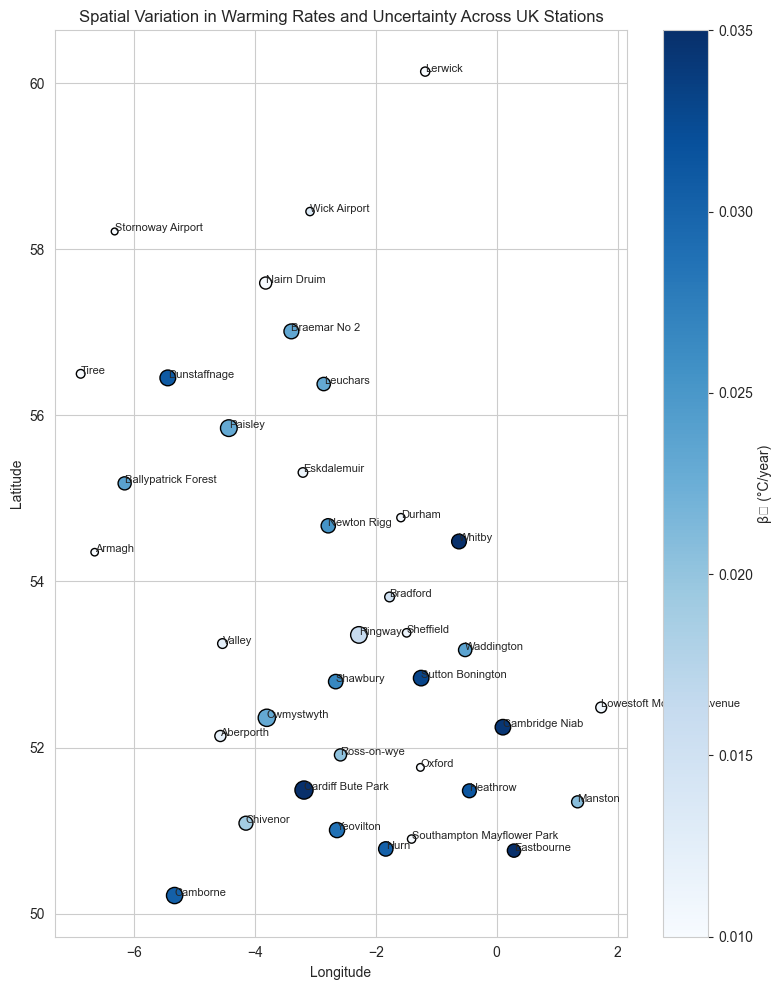

In [32]:
df = bootstrap_df.merge(meta_df[['Name','Latitude','Longitude']], 
                        left_on='Station', right_on='Name')

df['CI_width'] = df['CI_high'] - df['CI_low']

plt.figure(figsize=(8,10))
plt.scatter(
    df['Longitude'],
    df['Latitude'],
    c=df['Beta1_estimate'],
    s=10000*df['CI_width'],  # CI width controls point size
    cmap='Blues',
    edgecolor='black',
    vmin=0.01, vmax=0.035
)

for _, row in df.iterrows():
    plt.text(row['Longitude'], row['Latitude'], row['Station'], fontsize=8)

plt.colorbar(label="β₁ (°C/year)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Variation in Warming Rates and Uncertainty Across UK Stations")
plt.tight_layout()
plt.show()


From the spatial plot, some geographical structure in warming rates across the UK can be seen. While not as strong as the relationship between TMax changes rates and length of station operation, a north-south latitudinal pattern is observed. Far-north, maritime station, like Lerwick, show some of the lowest rate of temperature increase, consistent with colder temperatures in these climates. The majority of stations with higher rates of change of temperature are located in southern, inland locations (Cambridge, Heathrow).  This aligns with the south of the UK being more susceptible to continental warming influences ad urban, inland heating effects. 

### 3.4 Prediction Interval

To get a picture of possible future rates of temperature increase across the UK, a prediction interval for the rate of change of maximum temperature in August 2075 will be calculated. 

A prediction interval is generated using a fitted regression line and the interval accounts for two types of uncertainty: 
- Uncertainty in the fitted regression model (not knowing the true values of the coefficients)
- The error in the fit of the regression model
Unlike confidence intervals, prediction interval incorporate the additional uncertainty of the goodness of fit of the model. As a result, prediction intervals are substantially wider and represent possible future values of TMax. 

This prediction interval for the monthly average of the maximum temperatures in August 2027 can then be compared to historic vales of TMax in August. This helps to contextualise the prediction interval and gives an indication of whether 2075 will be significantly hotter than years in the last century. 

#### 3.4.1 Bootstrap procedure

The following steps were taken to calculate the prediction interval for TMax for a given station: 
- The predicted value of TMax from the original regression is obtains, using the estimates of the coefficients. 
- A distribution of bootstrapped predicted TMax values are generated. The same technique used for the bootstrapped confidence intervals is applied, which generates many sets of bootstrapped residuals and regression coefficients. 
- A residual is randomly selected from each bootstrapped set and used alongside the estimates fo the coefficients for that set to calculate a **bootstrapped predicted TMax value for Auguest 2075**. The result is a bootstrapped distribution of TMax predictions for August 2075, from which the prediction interval can be calculated.

A 95% prediction interval is used for this analysis. 

In [33]:
# First want predicted value of y, using given time. 
# Calculate t, sint and cost for aug 2075
# Then bootstrap 

pred_t = (2075 - first_year ) * 12 + 8 -1 # Calculate month for predicted value
x_pred = np.array([pred_t, np.sin(omega * pred_t), np.cos(omega * pred_t)])


def predict_future(station, x_pred, cols, repeats=B):

    reg = reg_results[station]['reg']
    X = reg_results[station]['X']
    y_hat = reg_results[station]['y_hat']
    residuals = reg_results[station]['residuals']

    # Same as bootstrap residuals function
    output = pd.DataFrame(data = dict([(c, np.empty(repeats)) for c in cols]))

    # Calculate predicted y using original linear regression equation
    y_pred_orig = reg.intercept_ + np.dot(reg.coef_, x_pred) 
    output['y_pred_orig'] = y_pred_orig

    for i in range (0, repeats):
        resampled_resid = resample(residuals, replace=True) # Resample residuals of regression with replacement 

        y_boot = y_hat + resampled_resid # Calculate bootstrap predicted y using bootstrap residuals

        reg_boot = LinearRegression().fit(X, y_boot)

        output.iloc[i, 0] = reg_boot.intercept_
        output.iloc[i,1:4] = reg_boot.coef_

        # Randomly sample residual to use from the residuals of this bootstrap linear regression fit 
        resid_pred = np.random.choice(resampled_resid)

        # Calculate bootstrap predicted y
        output.iloc[i, 5] = reg_boot.intercept_ + np.dot(reg_boot.coef_, x_pred) + resid_pred


    return output




In [34]:
# Loop through al stations 
prediction_results = []
pred_columns = ['beta_B0', 'beta_B1', 'beta_B2', 'beta_B3', 'y_pred_orig', 'y_pred_boot']

for station, results in reg_results.items():

    df = reg_results[station]['df']

    pred_df = predict_future(station, x_pred, pred_columns)

    pred_low = pred_df.y_pred_boot.quantile(0.025)
    pred_high = pred_df.y_pred_boot.quantile(0.975)


    prediction_results.append({
        'Station': station,
        'y_pred_orig': float(pred_df.y_pred_orig.max()),
        'pred_low': pred_low,
        'pred_high': pred_high
    })

# Create dataframe of prediction results
prediction_df = pd.DataFrame(prediction_results)




#### 3.4.2 Results for Selected Stations

Oxford (southern inland) and Lerwick (northern maritime) will be used to investigate the prediction interval results. 

It is useful to visualise the prediction interval for TMax in August 2075 in the context of historic August temperatures. A time series plot is used for this, including the raw TMax data, the fitted regression line, extrapolated to 2075, and the prediction interval for TMax in 2075. 


In [35]:
def plot_august_prediction_interval(station):

    # Get original regression info
    df = reg_results[station]['df'].copy()
    reg = reg_results[station]['reg']             
    y_hat = reg_results[station]['y_hat']

    # Filter for August only
    df_aug = df[df["Month"] == 8].sort_values("Year").copy()

    # Get prediciotn and PI values
    row = prediction_df[prediction_df["Station"] == station].iloc[0]
    y_pred_2075 = row["y_pred_orig"]
    pred_low = row["pred_low"]
    pred_high = row["pred_high"]

    # Extend time values up to 2075
    t_hist = df_aug["t"].values
    t_extended = np.append(t_hist, pred_t)

    X_ext = np.column_stack([
        t_extended,
        np.sin(omega * t_extended),
        np.cos(omega * t_extended)
    ])
    # Calculate values for extrapolated regression line
    y_ext = reg.predict(X_ext)
    years_extended = np.append(df_aug["Year"].values, 2075)


    plt.figure(figsize=(10,5))

    # Historical August TMax
    plt.scatter(df_aug["Year"], df_aug["TMax"],
                alpha=0.5, color="grey", label="Observed August TMax")

    # Fitted trend (historical only)
    plt.plot(df_aug["Year"], y_hat[df_aug.index],
             color="blue", linewidth=2, label="Fitted Regression Trend")

    # Extrapolated trend to 2075
    plt.plot(years_extended, y_ext,
             color="black", linestyle="--", linewidth=2, label="Extrapolated Trend")

    # 2075 prediction + PI 
    plt.errorbar(
        x=2075,
        y=y_pred_2075,
        yerr=[
            [abs(y_pred_2075 - pred_low)],     # lower interval
            [abs(pred_high - y_pred_2075)]   # upper interval
        ],
        fmt='o',
        color='red',
        capsize=5,
        label="Predicted TMax 2075 (95% PI)"
    )
    print(f"The prediction interval for the average maximum daily temperature in {station} in August 2075 is {pred_low.round(2)} to {pred_high.round(2)} degrees Celsius")
    plt.title(f"August TMax Trend and Prediction Interval — {station}")
    plt.xlabel("Year")
    plt.ylabel("Average Maximum Temperature (°C)")
    plt.legend()
    plt.tight_layout()
    plt.show()


The prediction interval for the average maximum daily temperature in Oxford in August 2075 is 18.32 to 25.8 degrees Celsius


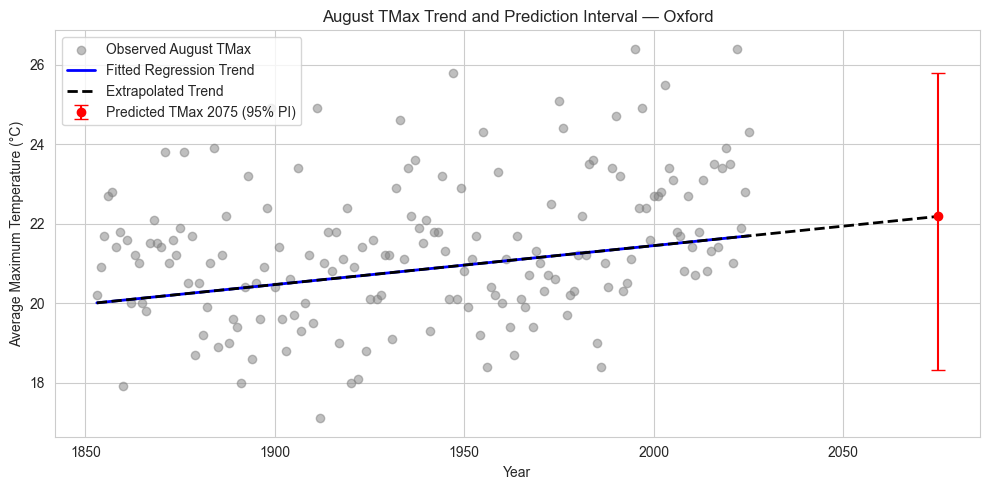

In [36]:
plot_august_prediction_interval("Oxford")

- The observed August TMax values span roughly 18 to 27 degrees Celsius over the period of recorded data. 
- The extrapolated regression trend line predicts a TMax value of approximately 22 degrees in August 2075, which is slightly above the majority of the historic observation but is still well within the range of historic observations
- The 95% prediction interval is very wide, spanning 18.6 to 25.6 degrees. A wide interval is expected, as it takes into account large year-on-year temperature variations, uncertainty from extrapolation and uncertainty in the fit of the regression model. 
- Importantly, the prediction interval almost fully overlaps with the range of the historic values. So, using the interval, August 2075 could be as cool or hot as many past Augusts, despite the positive rate of maximum temperature change found by the regression. 

The prediction interval for the average maximum daily temperature in Lerwick in August 2075 is 12.32 to 16.74 degrees Celsius


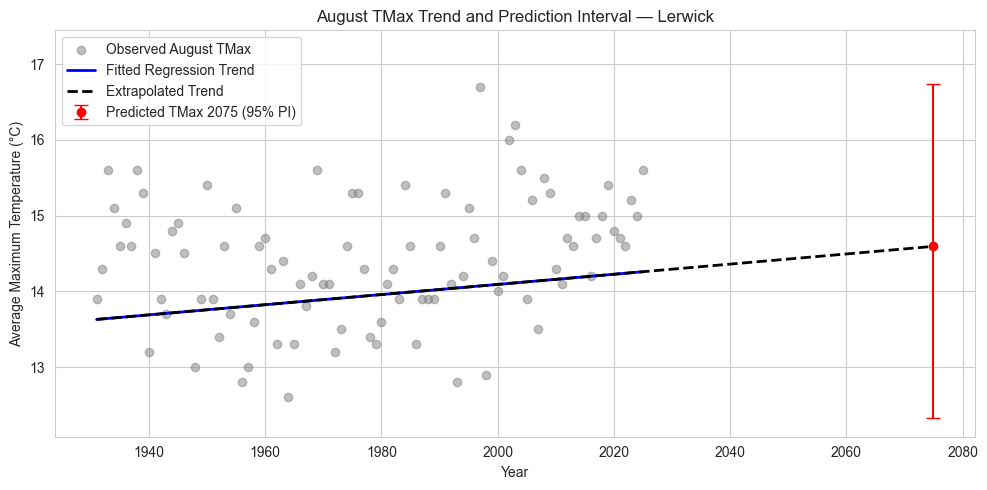

In [37]:
plot_august_prediction_interval("Lerwick")


- For Lerwick, historical temperatures rage from approximately 13 to 17 degrees Celsius. This is considerably cooler than Oxford, owing to its northern location. 
- The predicted TMax value from the extrapolated regression line is around 15 degrees.
- Again, the prediction interval is broad (12.4 to 16.7 degrees C), and overlaps almost entirely with the historic range, so, using the interval, August 2075 is unlikely to be hotter or cooler than Augusts already experienced. 

To get a better view of the overlap between prediction intervals and the distribution of historic August TMax data, the historic distributions are plotted below, with the 2075 prediction interval overlaid. This gives an idea of how far future conditions are likely to deviate from what has been observed in the past. 

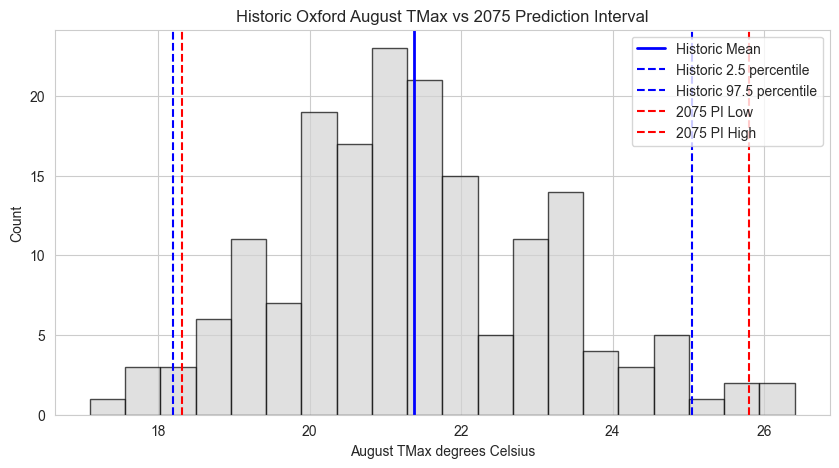

In [38]:
df_aug = reg_results["Oxford"]["df"]
df_aug = df_aug[df_aug["Month"] == 8]

historic_mean = df_aug["TMax"].mean()
historic_sd = df_aug["TMax"].std()
historic_min = df_aug["TMax"].min()
historic_max = df_aug["TMax"].max()

historic_ci_low = df_aug["TMax"].quantile(0.025)
historic_ci_high = df_aug["TMax"].quantile(0.975)

pred_low = float(prediction_df.loc[(prediction_df.Station == 'Oxford')]['pred_low'].iloc[0])
pred_high = float(prediction_df.loc[(prediction_df.Station == 'Oxford')]['pred_high'].iloc[0])


plt.figure(figsize=(10,5))
plt.hist(df_aug["TMax"], bins=20, color="lightgrey", edgecolor="black", alpha=0.7)
plt.axvline(historic_mean, color="blue", label="Historic Mean", linewidth=2)
plt.axvline(historic_ci_low, color="blue", linestyle="--", label="Historic 2.5 percentile")
plt.axvline(historic_ci_high, color="blue", linestyle="--", label="Historic 97.5 percentile")
plt.axvline(pred_low, color="red", linestyle="--", label="2075 PI Low")
plt.axvline(pred_high, color="red", linestyle="--", label="2075 PI High")

plt.title("Historic Oxford August TMax vs 2075 Prediction Interval")
plt.xlabel("August TMax degrees Celsius")
plt.ylabel("Count")
plt.legend()
plt.show()


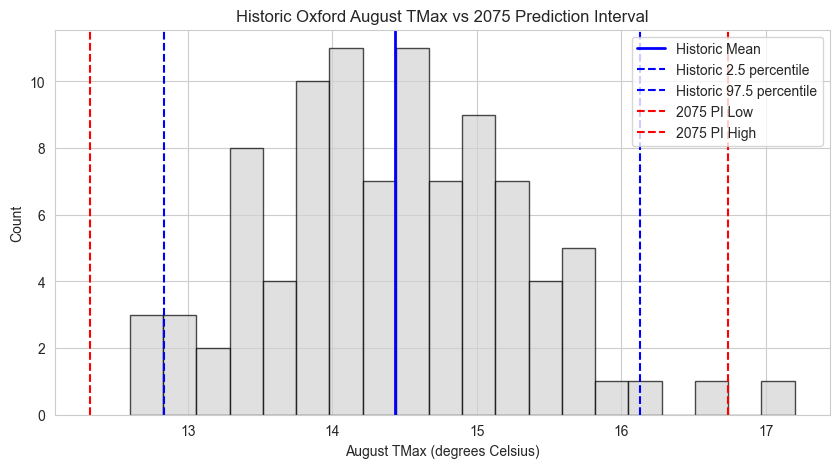

In [39]:
df_aug = reg_results["Lerwick"]["df"]
df_aug = df_aug[df_aug["Month"] == 8]

historic_mean = df_aug["TMax"].mean()
historic_sd = df_aug["TMax"].std()
historic_min = df_aug["TMax"].min()
historic_max = df_aug["TMax"].max()

historic_ci_low = df_aug["TMax"].quantile(0.025)
historic_ci_high = df_aug["TMax"].quantile(0.975)

pred_low = float(prediction_df.loc[(prediction_df.Station == 'Lerwick')]['pred_low'].iloc[0])
pred_high = float(prediction_df.loc[(prediction_df.Station == 'Lerwick')]['pred_high'].iloc[0])

plt.figure(figsize=(10,5))
plt.hist(df_aug["TMax"], bins=20, color="lightgrey", edgecolor="black", alpha=0.7)
plt.axvline(historic_mean, color="blue", label="Historic Mean", linewidth=2)
plt.axvline(historic_ci_low, color="blue", linestyle="--", label="Historic 2.5 percentile")
plt.axvline(historic_ci_high, color="blue", linestyle="--", label="Historic 97.5 percentile")
plt.axvline(pred_low, color="red", linestyle="--", label="2075 PI Low")
plt.axvline(pred_high, color="red", linestyle="--", label="2075 PI High")

plt.title("Historic Oxford August TMax vs 2075 Prediction Interval")
plt.xlabel("August TMax (degrees Celsius)")
plt.ylabel("Count")
plt.legend()
plt.show()

The above histogram plots of the historic distribution of August TMax values for Oxford and Lerwick clearly show how the prediction intervals (PIs) for 2075 sit relative to previously recorded data. 

For Oxford, the PI is shifted to slightly greater temperatures than the 95% range for the historic data. However, the level of overlap is large enough to say that there is unlikely to be a large disparity between the tMax temperatures observed in August 2075 and those observed in previous Augusts. that is not to say that the **overall** TMax values experienced throughout the year will not change: the regression performed in this section of the report has strongly indicated that tMax values are increasing with time. 

In Lerwick, the PI almost completely covers the range of historic values, so the TMax values observed in 2075 are unlikely to be dramatically different from historic recordings. 

It is expected that there will be slightly more certainty that August 2075 will be hotter than historic observations in Oxford. The station has been operating for decades longer than Lerwick, so there is less uncertainty in the regression model, which translates to slightly less uncertainty in the prediction of future values. 

## 4.Changing Pattern of Air Frost Days

The analysis in this section focusses on testing whether there is evidence that the number of days with air frost has changed over time. The frost variable in the dataset gives a count of the number of days in a given month that had air frost. 

To determine whether the number of frost days is changing with time, an independence test is used: we need to test whether the proportion of frost and no frost days is independent of time. I.e. if we took readings over the 10 decades, we would expect to see the same proportion of frost and no frost days for every decade, if frost were completely independent of time. 

A **chi-squared test** is used to test the independence of number of frost days and time. This is a form of hypothesis testing for categorical variables (Frost/NoFrost in this case) and it is used to determine whether two categorical variables are statistically related. In this case, the question asked is: does the pattern of frost/no frost counts change across decades, or could any difference be explained by random variation (chance)?

The test compares **observed** counts, obtained by constructing a contingency table from frost-time data, with **expected** counts. Expected counts are calculated under the assumption that frost occurrence is independent of the decade, so the frost/no frost proportions are the same in every decade. 

Using the observed and expected counts, the chi-squared statistic is calculated, giving a measure of how far the observed table is from the expected table. A value fo 0 would mean that the tables are identical (no evidence of change), while a large value provides evidence that frost is changing with time. 

So far, the chi-squared test statistic has been calculated from a sample. To model the sampling distribution of the test statistic, a chi-squared distribution is used. This is a function with degrees of freedom as a parameter and models the chi-squared statistic when the null hypothesis is true (no change in frost over time). Degrees of freedom (dof) are calculated from the number of rows and columns in a contingency table. The more rows and columns, the larger the table, and the more room for variation. 

The **p-value** is the area in the tail of the distribution before the observed value of chi-squared. It is the probability of seeing values as estrme or more extreme than the observed value, assuming frost and time are independent. If this probability is smaller than the significance level set before the test, then the null hypothesis of independence can be rejected and variation between frost and time is too great to be explained by chance. Therefore, there is statistical evidence of changing frost patters over time. p-values will be calculated for each station in the dataset, to investigate changing frost patterns. 




### 4.1 Handling Frost Data

To perform the chi-squared test, the data for each weather station must be cleaned and structured in the correct format. A contingency table will be constructed, detailing the number of frost and no frost days per decade. 

**Use of winter months only**  

The frost data was briefly examined in section 2.4 and it was seen that across all 37 weather stations and for all recorded months, the count of frost days for the summer months of June to August are **zero**. This expected with the increased temperatures experienced in the summer months. 

Summer provides no variation in frost occurrences and including the months of June to August in the contingency table would artificially inflate the 'no frost' category and would overpower any meaningful winter changes. Additionally, chi-sqaured testing requires that categories contain meaningful counts, so including summer months that always have zero frost days (meaningless), violates the test assumptions. 

Because the purpose of the chi-squared test is to assess changes in frost occurrence over time, a process that only operates in the winter season, only November, December, January February, and March data are included. Restricting the analysis to winter ensures that the categories contain meaningful variation and that the assumptions of the chi-squared test are satisfied.


**Handling missing data**

Some of the station records contain missing values for frost days. For this analysis, dropping months with missing values is not an appropriate approach: dropping a month of data would make the frost data for a decade in the contingency table incomplete and would change the structure of the contigency table The number of frost/no-frost decades would differ between decades, creating an unbalanced comparison, where some decades artificially appear to have fewer frost days simply because some data is missing, not because of a meaningful change in climate. 

Instead, missing values are imputed, using the mean of the values from the same month in nearby years. This avoids introducing bias to the independence test because it maintains equal sample sizes across decades. Averaging adjacent winter values is appropriate here because frost shows gradual year--on-year variability, so nearby values are likely to be similar. 


In [40]:
# Impute missing frost values 

def impute_frost_values(df):

    for idx, row in df[df.Frost.isna()].iterrows():

        month = row.Month
        year = row.Year

        nearby = df[(df.Month == month) & (abs(df.Year - year) <4) &(df.Frost.notna())]

        # Expand if not enough data points from nearby years
        if len(nearby) < 2:
            nearby = df[(df.Month == month) & (abs(df.Year - year) < 6) &(df.Frost.notna())]
        
        # If still no data to impute value, just use monthly mean for that station 
        if len(nearby) == 0:
            value = df[df.Month == month]['Frost'].mean()
            df.at[idx, 'Frost'] = value
        else: 
            df.at[idx, 'Frost'] = nearby['Frost'].mean()
    
    return df

**Constructing Contingency Tables**

For each station, a contingency table is constructed. The table details the total number of frost and no frost days in each decade for which data was recorded. The 'no frost' count for each month is calculated by subtracting the count of frost days from the total number of days in that month. 



### 4.2 Chi-Squared Tests for Independence

Once missing data is handled and the data is filtered for the winter months, contingency tables for the frost/no frost counts per decade are constructed for each station and a chi-squared test is performed on each. The results for the tests of all stations are collected in a dataframe. 

A significance level of 5% was used for the tests. Stations with p-values below 0.05 were interpreted as showing evidence of a change in the frequency of winter frost days across decades that is not due to random variation. In other words, the null hypothesis is rejected in these cases. 

In [41]:
# Function for days in month 
def days_in_month(month, year):
    if month == 2:
        # February - check for leap year
        if (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0):
            return 29
        else:
            return 28
    elif month in [1, 3, 12]:
        return 31
    else:
        return 30

def frost_independence_test (df, min_observations=10):


    winter_months = [1, 2, 3, 11, 12]  # Winter months to be included

    # Filter df for winter months
    df_filtered = df.loc[df.Month.isin(winter_months)].copy()
    df_filtered['Decade'] = (df_filtered['Year'] // 10) * 10

    # Impute missing frost values

    df_filtered = impute_frost_values(df_filtered)

    # Calculate number of days in month
    df_filtered = df_filtered.assign(
        DaysInMonth = df_filtered.apply(
            lambda row: days_in_month(row.Month, row.Year), axis=1
        )
    )   

    # No frost days equals ays in month minus frost days
    df_filtered['NoFrost'] = df_filtered['DaysInMonth'] -  df_filtered['Frost']

    # Remove invalid data - ensures there are no data where recorded frost days > days in month
    df_filtered = df_filtered[df_filtered['NoFrost'] >= 0]

    # Create contingency table of frost/no frost against decade

    contingency_table = df_filtered.pivot_table(
        index='Decade', 
        values=['Frost', 'NoFrost'],
        aggfunc='sum'
    )

    # Run chi-squared test
    test_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table, correction=False)

    return {
    'test_stat': test_stat,
    'p_value': p_value,
    'dof': dof,
    'significant': p_value < 0.05,
    'contingency_table': contingency_table
    }




The chi-squared test results for all 37 stations are summarised in the table below. 

In [42]:
# Perform on all 37 stations 
chi_squared_results = {}

for station, df in weather_data.items():
    chi_squared_results[station] = frost_independence_test(df)

chi_squared_df = pd.DataFrame.from_dict(chi_squared_results, orient='index')
chi_squared_df.index.name = 'Station'
chi_squared_df.reset_index(inplace=True)

display(chi_squared_df.loc[:,['Station', 'test_stat', 'p_value', 'significant']])

,Station,test_stat,p_value,significant
0,Aberporth,138.819220,4.176373e-26,True
1,Armagh,161.789833,1.179418e-25,True
2,Ballypatrick Forest,283.076879,3.447403e-58,True
3,Bradford,178.190690,1.002907e-31,True
4,Braemar No 2,46.792539,6.126971e-08,True
5,Camborne,56.920806,5.250630e-11,True
6,Cambridge Niab,72.331478,4.986481e-13,True
7,Cardiff Bute Park,15.839893,7.316369e-03,True
8,Chivenor,1.104851,9.929553e-01,False
9,Cwmystwyth,92.766116,8.063126e-18,True


At a glance, the vast majority of chi-squared values are large and p-values are very small (several tens of orders of magnitude smaller than the 0.05 significance level). Before looking further into the results, the initial impression is tht the observed frost frequencies over time are very different from the values expected for independent variables. 

To visualise the results more clearly, a bar chart of the negative log of the p-value for each station is plotted. he dashed red line marks the significance threshold for the chi-squared test. Any value greater than this means that there is statistical evidence that the frost and time variables are linked. 

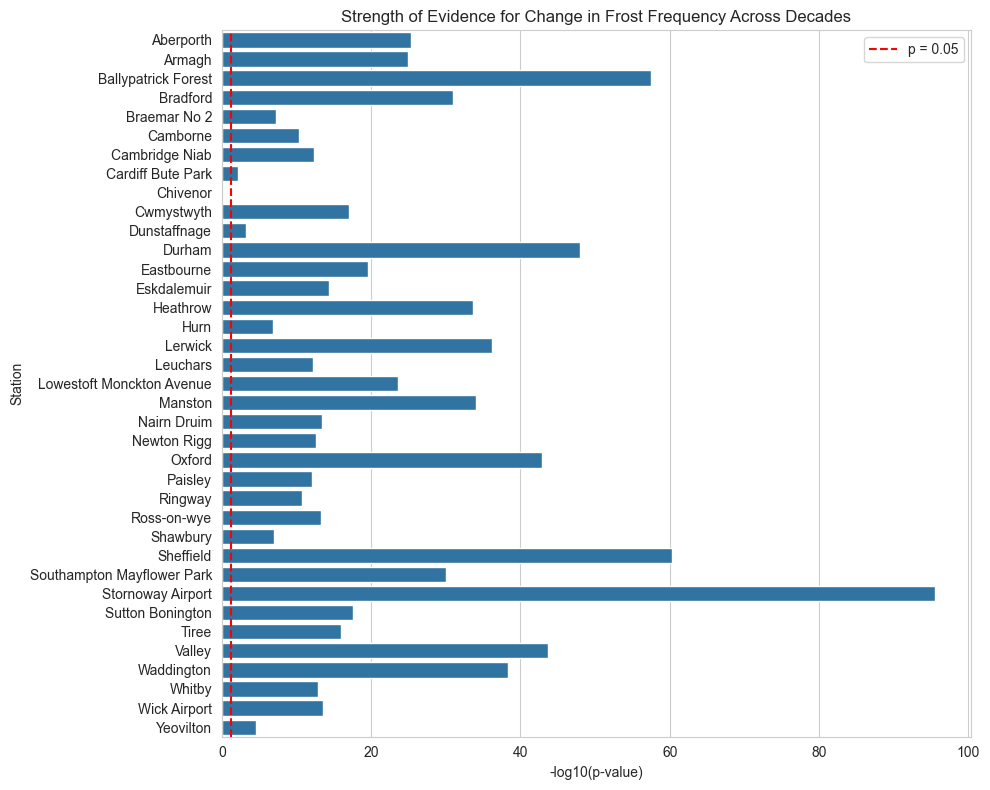

In [43]:

chi_squared_df["neglog_p"] = -np.log10(chi_squared_df["p_value"])

plt.figure(figsize=(10,8))
sns.barplot(data=chi_squared_df,y="Station", x="neglog_p", legend=False)

plt.axvline(-np.log10(0.05), color="red", linestyle="--", label="p = 0.05")
plt.xlabel("-log10(p-value)")
plt.ylabel("Station")
plt.title("Strength of Evidence for Change in Frost Frequency Across Decades")
plt.legend()
plt.tight_layout()
plt.show()


The bar chart shows the strength of statistical evidence for changes in winter frost day frequency across decades for all 37 stations. The negative log of the p-value is plotted, making it easier to interpret the very very small values. Larger values indicate stronger evidence against the null hypothesis of no change in frost over time. 

- Almost all stations show very strong evidence of change in frost day frequency. Many stations show values exceeding 20, corresponding to p-values smaller than 10^-20. This means that the probability of observing chance-based shifts in the number of frost days of this magnitude is extremely small. Stations such as sheffield ad Stornoway airport have exceptionally large log values, so there is overwhelming statistical evidence for a meaningful change in frost over time. 
- This result is consistent with the increasing temperatures across the UK, highlighted by the regression in the previous section. The UK has witnessed a substantial reduction in the frequency of frost days over the last century and the chi-squared test is very sensitive to such structural changes. 
- The non-significant result, Chivenor, has a p-value close to the significance threshold, suggesting that any observed fluctuations in frost day frequency with time are due to chance. Reasons for this result could be a milder climate with fewer frost days to begin with, or a shorter, more fragmented weather record that gives rise to unreliable results. This would need to be investigated further, 


To investigate whether there are any regional patterns in the results, a scatter plot mapping each station by its latitude and longitude is shown below. The colour and size of the marker represents the strength of the evidence (-log(p)) for a changing frequency of frost days across decades. Strong evidence is widespread across UK stations, so there is no strong geographical trend, though northern weather stations do have slightly larger p-values. This is consistent with a lesser reduction in frost days, which mirrors their colder climates. Stations with extremely strong evidence are evenly distributed across the country. This suggests that reduction in frost days with time is a national, not regional phenomenon. 

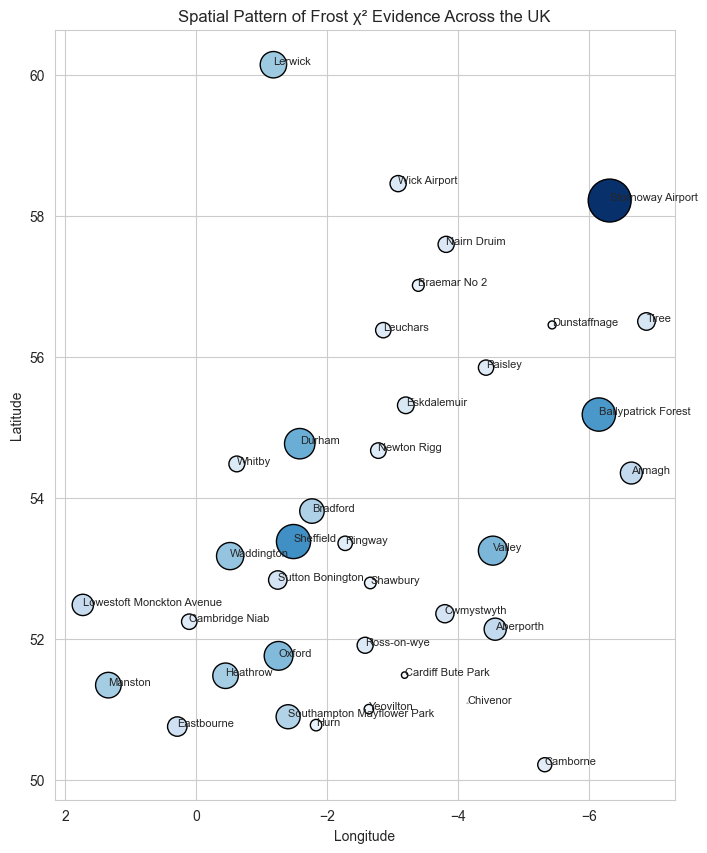

In [44]:
plot_df = chi_squared_df.merge(meta_df, left_on="Station", right_on="Name")


plt.figure(figsize=(8,10))
plt.scatter(
    plot_df['Longitude'],
    plot_df['Latitude'],
    c=plot_df['neglog_p'],
    s=10*plot_df['neglog_p'],  # 
    cmap='Blues',
    edgecolor='black'
)

for _, row in plot_df.iterrows():
    plt.text(row['Longitude'], row['Latitude'], row['Station'], fontsize=8)

plt.title("Spatial Pattern of Frost χ² Evidence Across the UK")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.gca().invert_xaxis()  # optional, maps look more UK-like
plt.show()


### 5. Examination of Statistical Evidence

#### 5.1 Evidence for climate change  

The analysis across Sections 2 to 4 provides clear evidence of climate change in the UK for the time period covered by the weather stations dataset. The plots for a handful of stations in Section 2 provided initial, qualitative evidence of rising temperatures and reduced frost and this was strengthened by statistical analysis, including regression, confidence intervals and chi-squared testing. The regression models fitted to TMax consistently produced positive estimates for the rate of change of temperature over time, and the bootstrapped confidence intervals for the estimated rates did not fall over zero. This presents string statistical evidence for a UK-wide trend in increasing temperatures, at a rate of around 1 to 3 degrees per century.

The frost data also supported the conclusion of warming. The initial plots showed a decline in the number of frost days observed over time and the chi-squared independence tests on frost day counts across decades provided statistical confirmation of this. The large chi-squared values and p-values significantly smaller than the 0.05 significance threshold provide strong evidence that frost frequency in winter months is dependent on time. This is consistent with rising temperatures reducing the number of winter days when temperatures fall below zero. 

Rainfall patterns were not investigated in depth, though the qualitative investigation suggested that there is significant variation in patterns observed in different regions of the UK. There was no discernable long-term trend and more in-depth analysis is needed in this area.

#### 5.2 Regional Variation  

There was notable regional variation, particularly for temperature trends, revealed in the analysis. Southern and central stations tended to show stronger warming trends compared with northern and coastal locations. This was reflected in the size and width of the confidence intervals obtained from the regression models. The dependence of the number of frost days observed on time was consistently strong across the county, but the strength of dependence did vary somewhat geographically, with some Scottish and northern stations showing smaller changes. These differences suggest that climate change is occurring in different ways, and at different rates, across the UK. 

Data coverage also contributed to differences in statistical results, such as confidence intervals, between stations. Stations that have been operating over longer periods of time provided more stable estimates of long-term change, while newer stations, which cover mostly recent years, sometimes produced larger trend estimates because they capture only the period of rapid recent warming. 


#### 5.3 Data Reliability and Limitations  

The weather station data used in this report has several limitations that could have affected the quality of the statistical evidence presented. Temperature and frost data were missing values for multiple stations and, although these were handled by being dropped or imputed before conducting statistical analysis, they may have had a negative impact on the reliability of the results. Stations also differ in the length of their historical records, something that was seen to impact the bootstrapped confidence intervals calculated for rate of temperature change, and means that accurate comparisons between stations is more difficult. Also, the quality of measurements may have improved over time, introducing inconsistencies that have not been accounted for. 

#### 5.4 Recommendations for Future Work  

- To get a better statistical picture of how weather patterns are changing in the UK, it would be useful to carry out analyses on a larger dataset, taking data from a greater number of UK weather stations and making sure to include regions that were under-sampled in this analysis. 
- This report conducts a fairly basic statistical analysis of the data. More in-depth evidence of UK climate change could be obtained by using more sophisticated statistical techniques, like time-series composition to better isolate long term change. 
- Additional climate variables, such as wind speed and storm frequency could be included. It would be beneficial to investigate extreme weather events, like droughts, heatwaves, flooding and storms. Increased frequency of extreme weather events is a known indicator of climate change. 
- Regional differences could be investigated more closely, using factors like distance from sea, altitude and population density to help to explain regional trends.